# QUANTITATIVE RESEARCH

The traditional way of building an investment portfolio is a two-step process that separates parameter estimation from optimization: 
- First, expected returns and dependence relationships (covariances) between assets are estimated.
- Second, these estimates are plugged into a mathematical model, to find the optimal mix of assets accordingly to the objective. 

The main issue with this “estimate-then-optimize” approach is that both steps are treated as separate tasks, leading to several issues, in particular with multivariate time series data: 
- First, estimation errors get magnified during the optimization process. 
- Second, the method focuses on the wrong goal – creating the best statistical model, rather than finding the parameters that will lead to the best decision in the future. 
- Third, it gets trickier as dimensions (e.g. portfolio assets) increase. Accurately estimating how hundreds or thousands of assets will interact with each other (a high-dimensional problem) is incredibly difficult and statistically fragile. State-of-the-art methods require a huge amount of effort to get this estimation right, which remains a major hurdle.

Machine Learning applies in portfolio management in two main ways. 
- The first approach involves forecasting, where models predict stock movements to inform a rule-based system. 
- The second approach uses Reinforcement Learning (RL), where an agent directly learns to execute actions (buy, sell, hold) by optimizing for long-term rewards, making it ideal for scenarios where the final outcome is only known at the end of a trading period.

**This notebook objective is to develop of policy (strategy) for building a portfolio. The portfolio is essentially an allocation of available resources across various assets. The policy then needs to restructure the portfolio over time as new information becomes available.**

In simple terms: **Given histories of 3 different assets (equities, bonds and gold), how would you allocate a fixed amount of money between these stocks every day that maximize the likelihood of returns.**

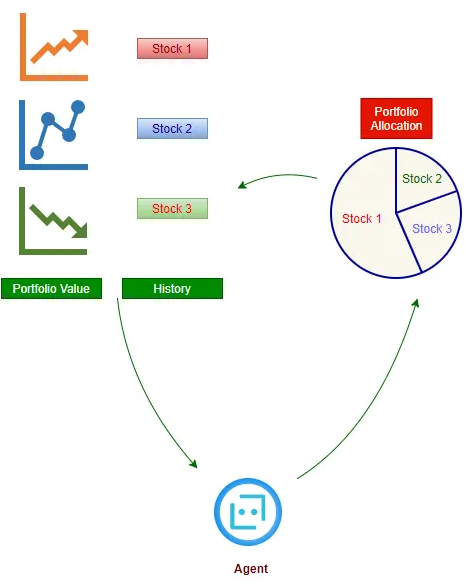

**Your role**: Develop a reinforcement learning model — an agent that allocates stocks at every time step by observing the indicators for each stock. In more details, your goal is to design an agent that interacts with a trading environment to maximize portfolio value. In this setup, each day should represent the agent's decision on asset allocation (e.g., 30% equities, 30% bonds, 30% gold). Based on the performance of this allocation, the agent receives a positive or negative reward. Through iterative learning, the agent refines its strategy to identify the optimal asset allocation for any given market state. Ultimately, you can compare your RL policy with Markowitz’ efficient frontier approach as natural benchmark. Cherry on the cake : include transaction costs - 2 bps for bonds, 5 bps for stocks and 10 bps for gold (1 bp = 0.01%)

**Rules**: 
- From PPO to DPO, choose the RL approach that suits best accordingly to the objective from your point of view.
- Please defend and motivate your choices.
- Be short and clear

**Data**: Attached dataset contains the daily returns from 4th of January, 1999 until 30th of September, 2025, for 3 assets 
- Equities (MSCI World Index, MXWD Index)
- Gold (XAU Curncy)
- Fixed-Income (Bloomberg Global Aggregate TR Index)

Only the attached data must be used in the context of the exercice.

## Problem Formulation (Mathematical Setup) and Why PPO

### Mathematical Formulation

We consider a daily rebalancing portfolio over three assets. Let:

- `r_t` be the vector of daily returns at day *t*  
- `w_t` be the portfolio weights chosen at day *t*  
- `V_t` be the portfolio value at the start of day *t*

The portfolio weights satisfy the simplex constraint:

$$
w_t \in \Delta^3 \quad \text{with} \quad
\Delta^3 = \left\{ w \in \mathbb{R}^3 \; \middle| \; w_i \ge 0,\ \sum_{i=1}^{3} w_i = 1 \right\}
$$

The portfolio value evolves according to:

$$
V_{t+1} = V_t \cdot \left( 1 + w_t^\top r_t - \text{TC}_t \right)
$$

Transaction costs are modeled as linear costs on turnover:

$$
\text{TC}_t = \sum_{i=1}^{3} c_i \, \lvert w_{t,i} - w_{t-1,i} \rvert
$$

where `c_i` are one-way transaction cost rates (e.g. 5 bps = 0.0005).

The state observed by the agent is defined as:

$$
s_t = \left[ r_{t-L:t-1},\; w_{t-1} \right]
$$

i.e. a rolling window of past returns of length `L`, concatenated with the current portfolio weights.

The agent learns a policy `π_θ` mapping states to portfolio weights by maximizing the expected discounted return:

$$
\max_{\theta} \; \mathbb{E} \left[ \sum_{t=1}^{T} \gamma^{t-1}
\log \left( \frac{V_{t+1}}{V_t} \right) \right]
$$

In a first approach, we will focus on the simple logarithmic return:

$$
r_t = \log \left( \frac{V_{t+1}}{V_t} \right)
$$

Optionally, the reward is regularized to control risk and concentration in order to avoid the model buying only one asset (as we will see later):

$$
r_t =
\log \left( \frac{V_{t+1}}{V_t} \right)
- \lambda_{\text{var}} \cdot (w_t^\top r_t)^2
- \lambda_{\text{herf}} \cdot \sum_{i=1}^{3} w_{t,i}^2
$$


---

### Why Proximal Policy Optimization (PPO)

We choose **Proximal Policy Optimization (PPO)** for the following reasons:

1. **Stable policy updates**  
   Portfolio allocation is highly sensitive to small changes in weights. PPO’s clipped objective constrains policy updates, preventing destructive jumps and improving training stability.

2. **Continuous action compatibility**  
   Portfolio weights live in a continuous space. PPO naturally supports continuous policies, making it well suited for direct asset allocation without discretization.

3. **Robustness under noisy rewards**  
   Financial returns are noisy and non-stationary. PPO has proven robust in such settings and is widely used as a strong baseline in financial reinforcement learning.

Overall, PPO provides a pragmatic trade-off between stability, expressiveness, and implementation simplicity, making it a natural choice for end-to-end portfolio allocation under transaction costs.


In [345]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import cvxpy as cp



In [346]:
df = pd.read_excel('RL_toy_data.xlsx', index_col=0, parse_dates=True)


## A quick Data Analysis

In [347]:
def plot_return(df: pd.DataFrame):
    plt.figure(figsize=(12, 4))
    df.plot(ax=plt.gca())
    plt.title("Rendements journaliers")
    plt.ylabel("Return")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_cumulative_assets(df: pd.DataFrame):
    cum = (1.0 + df).cumprod() - 1.0

    plt.figure(figsize=(12, 5))
    cum.plot(ax=plt.gca())
    plt.title("Rendement cumulé par actif")
    plt.ylabel("Rendement cumulé")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_correlation(df: pd.DataFrame):
    corr = df.corr()

    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)

    plt.title("Matrice de corrélation")
    plt.tight_layout()
    plt.show()

def plot_rolling_vol(df: pd.DataFrame, window: int = 252):
    rolling_vol = df.rolling(window).std() * np.sqrt(252)

    plt.figure(figsize=(12, 5))
    rolling_vol.plot(ax=plt.gca())
    plt.title(f"Volatilité annualisée glissante ({window} jours)")
    plt.ylabel("Volatilité")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


strat

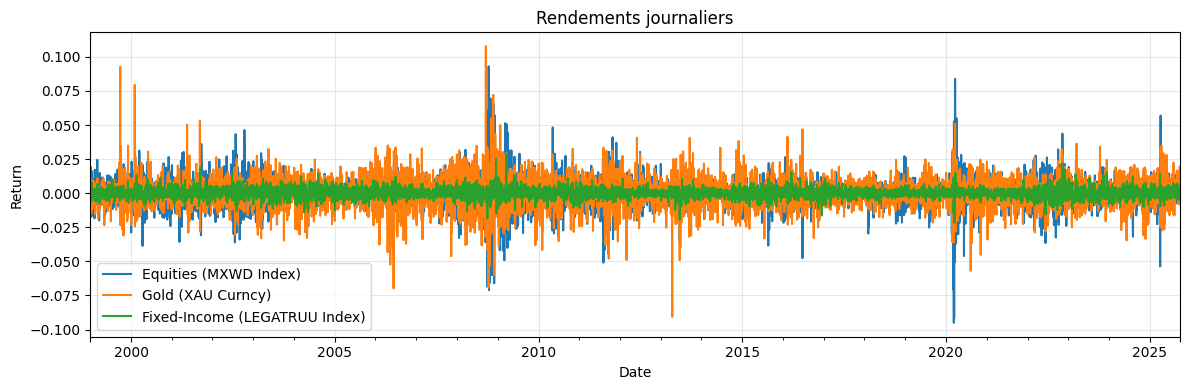

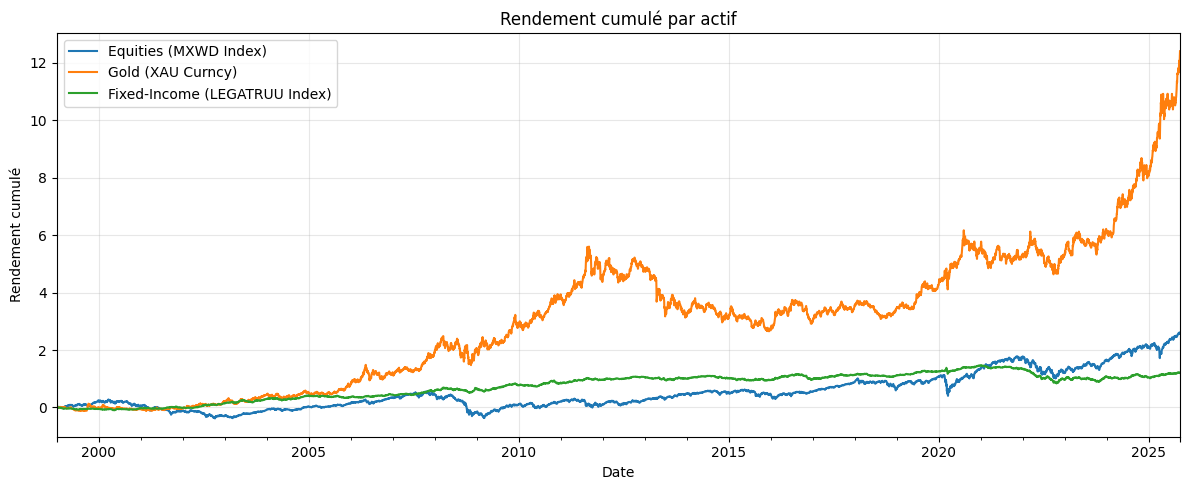

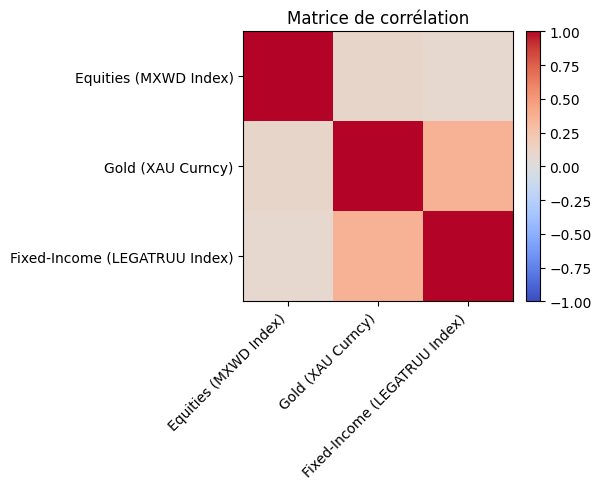

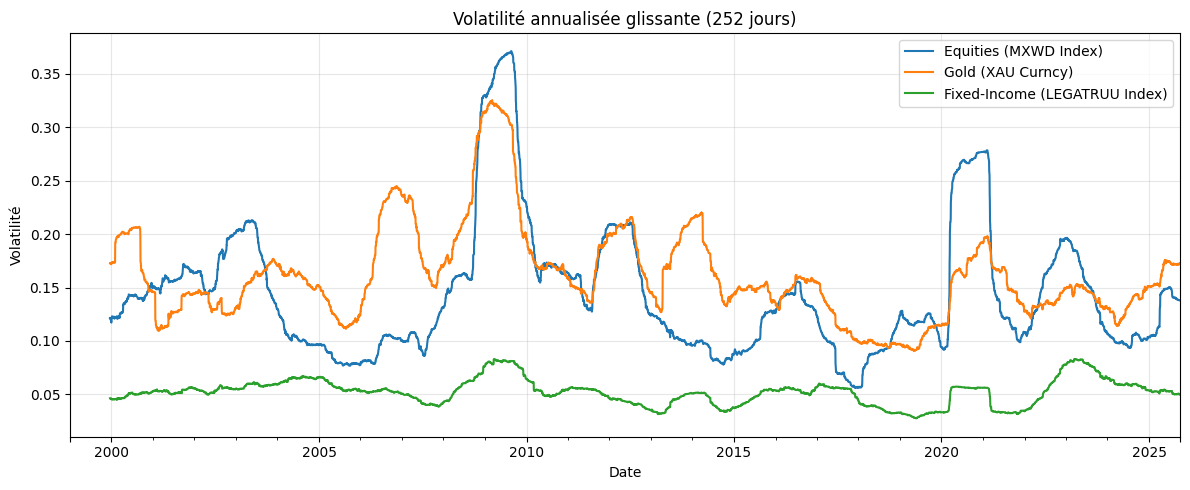

In [348]:
plot_return(df)
plot_cumulative_assets(df)
plot_correlation(df)
plot_rolling_vol(df)

## Data Insights and Expected Model Behavior

The exploratory analysis of the data reveals a few key characteristics.

- **Gold shows a very strong cumulative return** over the sample period, despite significant fluctuations.
- **Equities and gold are both highly volatile**, with frequent regime changes.
- **Cross-asset correlations are generally low**, indicating meaningful diversification opportunities.

Given these observations, we can anticipate different behaviors from the two approaches.

**PPO (Reinforcement Learning)** is expected to:
- exploit the strong long-term performance of gold,
- dynamically adjust allocations in response to volatility and market regimes,
- produce smoother, more stable portfolios once transaction costs are accounted for.

**Markowitz mean–variance optimization**, on the other hand:
- relies on noisy estimates of expected returns and covariances,
- may react excessively to short-term estimation changes,
- is likely to generate higher turnover and suffer more from transaction costs.

Overall, the data favors an end-to-end decision-making approach such as PPO, which can directly adapt to volatility and weak correlations without relying on fragile parameter estimates.


## Advantage Estimation and PPO Objective

### Advantage Function

In policy-gradient methods, the **advantage function** measures how much better an action is compared to the agent’s baseline expectation:

$$
A_t = Q(s_t, a_t) - V(s_t)
$$

In practice, the true advantage is unknown and must be estimated. PPO follows the approach introduced in *Mnih et al. (2016)* and uses **finite-horizon advantage estimators**, which are particularly well suited for sequential data such as financial time series.

For a rollout of length \(T\), the truncated return-based estimator is:

$$
\hat{A}_t =
- V(s_t) + r_t + \gamma r_{t+1} + \cdots + \gamma^{T-t} V(s_T)
$$

More generally, PPO uses **Generalized Advantage Estimation (GAE)**, which trades off bias and variance via a parameter \(\lambda\):

$$
\hat{A}_t =
\delta_t + (\gamma \lambda)\delta_{t+1} + \cdots + (\gamma \lambda)^{T-t-1}\delta_{T-1}
$$

where the temporal-difference residual is:

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

Setting \(\lambda = 1\) recovers the finite-horizon estimator above, while smaller values reduce variance at the cost of bias.  
This is especially important in finance, where rewards are noisy and trajectories are long.

---

### Full PPO Objective

When using an actor–critic architecture with a shared neural network, the training objective combines three terms:

1. **Clipped policy surrogate**
2. **Value function loss**
3. **Entropy bonus** (to encourage exploration)

The objective maximized at each iteration is:

$$
L^{\text{CLIP+VF+S}}(\theta) =
\mathbb{E}_t \left[
L^{\text{CLIP}}_t(\theta)
- c_1 L^{\text{VF}}_t(\theta)
+ c_2 S\big[\pi_\theta\big](s_t)
\right]
$$

with:
- \(L^{\text{CLIP}}_t(\theta)\) the PPO clipped surrogate,
- \(L^{\text{VF}}_t(\theta) = (V_\theta(s_t) - V_t^{\text{target}})^2\) the value-function loss,
- \(S[\pi_\theta](s_t)\) the policy entropy,
- \(c_1, c_2\) weighting coefficients.

The entropy bonus prevents premature convergence and helps maintain sufficient exploration, which is critical in non-stationary environments such as financial markets.

---

### PPO Algorithm (Actor–Critic Style)

The PPO training procedure follows the algorithm below.

**Algorithm 1: Proximal Policy Optimization (PPO)**



for iteration=1, 2, . . . do
    for actor=1, 2, . . . , N do
        Run policy πθold in environment for T timesteps
        Compute advantage estimates Aˆ
    end for
    Optimize surrogate L wrt θ, with K epochs and minibatch size M ≤ NT
    θold ← θ
end for

In [ ]:
# ============================================================
# PPO Portfolio Allocation (Equities / Bonds / Gold)
# - Actions = logits (R^3) -> softmax -> weights on simplex
# - Reward = log-portfolio growth (after transaction costs)
# ============================================================

# -----------------------------
# Hyperparameters (PPO / GAE)
# -----------------------------
GAMMA = 0.99            # γ
LAMBDA = 0.95           # λ (GAE)
EPSILON = 0.2           # ε (clip)
C1 = 0.5                # value loss weight
C2 = 0.01               # entropy weight
LR = 3e-4               # learning rate

ROLLOUT_LEN = 256#256       # steps collected per iteration
BATCH_SIZE = 64
EPOCHS = 10 #20
MAX_GRAD_NORM = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Utils
# -----------------------------
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def softmax_stable(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / (np.sum(ex) + 1e-12)


# -----------------------------
# Environment
# -----------------------------
class PortfolioEnv:
    """
    Daily rebalancing environment on returns.

    Convention used here (no look-ahead):
    - State at time t uses information up to t-1 (a window of past returns).
    """

    def __init__(
        self,
        returns_df: pd.DataFrame,
        window_size: int = 20,
        init_value: float = 100.0,
        # Order MUST match columns in returns_df
        # Example: columns = ["Equities", "Bonds", "Gold"]
        cost_bps=None,
        random_start: bool = False,
        min_episode_len=None,
        lambda_var: float=10.0,
        lambda_herf: float=0.1
    ):
        assert isinstance(returns_df, pd.DataFrame)
        assert returns_df.shape[1] == 3

        self.returns_df = returns_df.copy()
        self.dates = self.returns_df.index
        self.returns = self.returns_df.values.astype(np.float64)  # shape (T, 3)

        self.window_size = int(window_size)
        self.init_value = float(init_value)

        if cost_bps is None:
            # Equities 5 bps, Bonds 2 bps, Gold 10 bps
            cost_bps = np.array([0.0005, 0.0010, 0.0002], dtype=np.float64)
        self.cost_bps = np.asarray(cost_bps, dtype=np.float64)
        assert self.cost_bps.shape == (3,)

        self.random_start = bool(random_start)
        self.min_episode_len = min_episode_len
        self.lambda_var=float(lambda_var)
        self.lambda_herf=float(lambda_herf)
        self.reset()

    def reset(self):
        self.t = self.window_size  # first tradable return index
        #for multiple episode random start
        if self.random_start:
            if self.min_episode_len is None:
                raise ValueError("min_episode_len must be set when random_start=True")
            high = len(self.returns) - self.min_episode_len
            self.t = np.random.randint(self.window_size, high)

        self.val = self.init_value
        self.w = np.array([1/3, 1/3, 1/3], dtype=np.float64)  # start equal weights

        self.done = False
        return self._get_state()

    def _get_state(self):
        #State = [past returns window (window_size x 3), current weights (3)]
        #Flattened into 1D vector.
        hist = self.returns[self.t - self.window_size:self.t, :]  # (window, 3)
        state = np.concatenate([hist.flatten(), self.w], axis=0).astype(np.float32)
        return state

    def step(self, action_logits: np.ndarray):
        """
        action_logits: shape (3,) or (1,3)
        """
        if self.done:
            raise RuntimeError("Environment is done. Call reset().")

        action_logits = np.asarray(action_logits).reshape(-1)
        assert action_logits.shape[0] == 3

        # target weights from logits (stable softmax)
        target_w = softmax_stable(action_logits)  # sums to 1, positive

        # Apply today's return to current portfolio
        r_t = self.returns[self.t, :]  # (3,)

        prev_val = self.val  # TRUE previous value (critical fix)


        delta_w = np.abs(target_w - self.w)

        if np.sum(delta_w) > 1e-3:
            turnover = float(delta_w.sum())
            transaction_cost = float(np.sum(delta_w * self.cost_bps)) * self.val
            val_after_cost = max(self.val - transaction_cost, 1e-12)
            w_trade = target_w.astype(np.float64)
        else:
            turnover = 0.0
            transaction_cost = 0.0
            val_after_cost = self.val
            w_trade = self.w.astype(np.float64)

        ####(2) APPLY today's return using weights held during the day
        gross_ret = 1.0 + float(np.dot(w_trade, r_t))
        gross_ret = max(gross_ret, 1e-12)
        self.val = max(val_after_cost * gross_ret, 1e-12)

        ####(3) DRIFT weights after the market move (end-of-day weights)
        w_drifted = (w_trade * (1.0 + r_t)) / gross_ret
        self.w = w_drifted.astype(np.float64)
        
        
        #### Reward = log growth after costs (critical fix)
        reward = float(np.log(self.val / max(prev_val, 1e-12)))

        #OPTIONAL PENALITIES
        # ---- Concentration penalty (Herfindahl)
        H = float(np.sum(self.w ** 2))          
        reward -= self.lambda_herf * (H - 1/3)

        # ---- Variance (quadratic) penalty
        p_t = float(np.dot(w_trade, r_t))   # portfolio return
        reward -= self.lambda_var * (p_t ** 2)

        ##### Advance time
        self.t += 1
        if self.t >= len(self.returns):
            self.done = True

        next_state = self._get_state() if not self.done else None
        info = {
            "date": self.dates[self.t - 1] if (self.t - 1) < len(self.dates) else None,
            "value": self.val,
            "turnover": turnover,
            "transaction_cost": transaction_cost,
            "weights": self.w.copy(),
        }
        return next_state, reward, self.done, info


# -----------------------------
# Actor-Critic Network to learn the policy and value function
# -----------------------------
class ActorCritic(nn.Module):
    def __init__(self, state_dim: int, action_dim: int = 3, hidden_dim: int = 128):
        super().__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Actor outputs mean logits
        self.actor_mean = nn.Linear(hidden_dim, action_dim)

        # Learnable log-std (global per action dim)
        self.actor_logstd = nn.Parameter(torch.zeros(action_dim))

        # Critic outputs scalar V(s)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        raise NotImplementedError("Use act() / value().")

    #Sample action whith normal distribution, mean depends on state, std is learned parameter
    def act(self, state: torch.Tensor):
        features = self.feature_layer(state)
        mean = self.actor_mean(features) #size (batch_size, action_dim)
        logstd = self.actor_logstd.expand_as(mean) #size (batch_size, action_dim)
        std = torch.exp(logstd) 

        dist = Normal(mean, std)
        action = dist.sample()


        logprob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)

        value = self.critic(features).squeeze(-1)
        return action, logprob, entropy, value

    def evaluate_actions(self, state: torch.Tensor, action: torch.Tensor):
        features = self.feature_layer(state)
        mean = self.actor_mean(features)
        logstd = self.actor_logstd.expand_as(mean)
        std = torch.exp(logstd)

        dist = Normal(mean, std)
        logprob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        value = self.critic(features).squeeze(-1)
        return logprob, entropy, value


# -----------------------------
# PPO Buffer + GAE
# -----------------------------
def compute_gae(rewards, values, dones, last_value, last_done, gamma=GAMMA, lam=LAMBDA):
    """
    rewards: (T,)
    values:  (T,)
    dones:   (T,)  where done[t] is terminal after taking step t
    last_value: scalar V(s_{T})
    last_done:  bool done at end of rollout
    """
    T = len(rewards)
    adv = np.zeros(T, dtype=np.float32)
    last_gae = 0.0

    for t in reversed(range(T)):
        next_nonterminal = 0.0 if dones[t] else 1.0
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_gae = delta + gamma * lam * next_nonterminal * last_gae
        adv[t] = last_gae

    returns = adv + values.astype(np.float32)
    return adv, returns


# -----------------------------
# PPO Trainer
# -----------------------------
class PPOTrainer:
    def __init__(self, env: PortfolioEnv):
        self.env = env

        dummy_state = env.reset()
        self.state_dim = int(dummy_state.shape[0])
        self.action_dim = 3

        self.agent = ActorCritic(self.state_dim, self.action_dim).to(DEVICE)
        self.optimizer = optim.Adam(self.agent.parameters(), lr=LR)

        self.last_state = torch.tensor(dummy_state, dtype=torch.float32, device=DEVICE)
        self.last_done = False

    def collect_rollout(self, rollout_len=ROLLOUT_LEN):
        states = []
        actions = []
        logprobs = []
        entropies = []
        values = []
        rewards = []
        dones = []

        for _ in range(rollout_len):
            with torch.no_grad():
                action, logp, ent, val = self.agent.act(self.last_state.unsqueeze(0))
            action_np = action.squeeze(0).cpu().numpy()

            next_state_np, reward, done, info = self.env.step(action_np)

            # store transition
            states.append(self.last_state.cpu().numpy())
            actions.append(action.squeeze(0).cpu().numpy())
            logprobs.append(float(logp.item()))
            entropies.append(float(ent.item()))
            values.append(float(val.item()))
            rewards.append(float(reward))

            # CRITICAL FIX: store CURRENT done, not previous done
            dones.append(bool(done))

            # advance
            if done:
                next_state_np = self.env.reset()
                self.last_done = True
            else:
                self.last_done = False

            self.last_state = torch.tensor(next_state_np, dtype=torch.float32, device=DEVICE)

        # bootstrap value
        with torch.no_grad():
            last_val = self.agent.critic(self.agent.feature_layer(self.last_state.unsqueeze(0))).squeeze().item()

        batch = {
            "states": np.asarray(states, dtype=np.float32),
            "actions": np.asarray(actions, dtype=np.float32),
            "logprobs": np.asarray(logprobs, dtype=np.float32),
            "values": np.asarray(values, dtype=np.float32),
            "rewards": np.asarray(rewards, dtype=np.float32),
            "dones": np.asarray(dones, dtype=bool),
            "last_value": float(last_val),
            "last_done": bool(self.last_done),
        }
        return batch

    def update(self, batch):
        adv, rets = compute_gae(
            rewards=batch["rewards"],
            values=batch["values"],
            dones=batch["dones"],
            last_value=batch["last_value"],
            last_done=batch["last_done"],
            gamma=GAMMA,
            lam=LAMBDA,
        )

        # normalize advantages
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        states = torch.tensor(batch["states"], dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(batch["actions"], dtype=torch.float32, device=DEVICE)
        old_logprobs = torch.tensor(batch["logprobs"], dtype=torch.float32, device=DEVICE)
        returns = torch.tensor(rets, dtype=torch.float32, device=DEVICE)
        advantages = torch.tensor(adv, dtype=torch.float32, device=DEVICE)

        n = states.shape[0]
        idx = np.arange(n)

        for _ in range(EPOCHS):
            np.random.shuffle(idx)
            for start in range(0, n, BATCH_SIZE):
                mb = idx[start:start + BATCH_SIZE]

                mb_states = states[mb]
                mb_actions = actions[mb]
                mb_old_logp = old_logprobs[mb]
                mb_adv = advantages[mb]
                mb_returns = returns[mb]

                new_logp, entropy, value = self.agent.evaluate_actions(mb_states, mb_actions)

                ratio = torch.exp(new_logp - mb_old_logp)
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1.0 - EPSILON, 1.0 + EPSILON) * mb_adv
                policy_loss = -torch.min(surr1, surr2).mean()

                value_loss = (mb_returns - value).pow(2).mean()

                entropy_loss = -entropy.mean()

                loss = policy_loss + C1 * value_loss + C2 * entropy_loss

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.agent.parameters(), MAX_GRAD_NORM)
                self.optimizer.step()

    def train(self, total_steps: int = 400_000):
        steps = 0
        while steps < total_steps:
            batch = self.collect_rollout(ROLLOUT_LEN)
            self.update(batch)
            steps += ROLLOUT_LEN



# -----------------------------
# Evaluation (deterministic)
# -----------------------------
def evaluate_agent(agent: ActorCritic, env: PortfolioEnv) -> pd.Series:
    state = env.reset()
    done = False

    values = [env.val]
    dates = []

    while not done:
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            features = agent.feature_layer(s.unsqueeze(0))
            action_logits = agent.actor_mean(features).squeeze(0).cpu().numpy()

        next_state, reward, done, info = env.step(action_logits)

        values.append(info["value"])
        dates.append(info["date"])

        state = next_state if next_state is not None else state
    
    # Align index length with values:
    # dates correspond to each step; values has initial value + one per step
    # We'll index values[1:] by dates, and keep initial value separately.
    perf = pd.Series(values[1:], index=pd.to_datetime(dates), name="portfolio_value")
    perf.attrs["initial_value"] = values[0]
    return perf




In [377]:
cost_bps = np.array([0.0005, 0.0010, 0.0002], dtype=np.float64)
# df already loaded, shape (6977, 3), indexed by Date
df = df.copy().sort_index().dropna()
assert df.shape == (6977, 3) or df.shape[1] == 3

# Costs aligned to df columns:
cost_bps = np.array([0.0005, 0.0010, 0.0002], dtype=np.float64)

split_date = "2020-12-31"
df_train = df.loc[:split_date].copy()
df_test  = df.loc[pd.to_datetime(split_date) + pd.Timedelta(days=1):].copy()


env_train = PortfolioEnv(df_train, window_size=60, cost_bps=cost_bps,lambda_var=0.0,lambda_herf=0.0)
env_test  = PortfolioEnv(df_test,  window_size=60, cost_bps=cost_bps,lambda_var=0.0,lambda_herf=0.0)

set_seed(42)

trainer = PPOTrainer(env_train)
trainer.train(total_steps=600_000)


perf_test = evaluate_agent(trainer.agent, env_test)
print("Initial value:", perf_test.attrs["initial_value"])
print("Final value:", perf_test.iloc[-1])
print(perf_test.tail())


Initial value: 100.0
Final value: 223.07851129884938
2025-09-24    215.980146
2025-09-25    216.747682
2025-09-26    217.356986
2025-09-29    221.609655
2025-09-30    223.078511
Name: portfolio_value, dtype: float64


<Figure size 640x480 with 0 Axes>

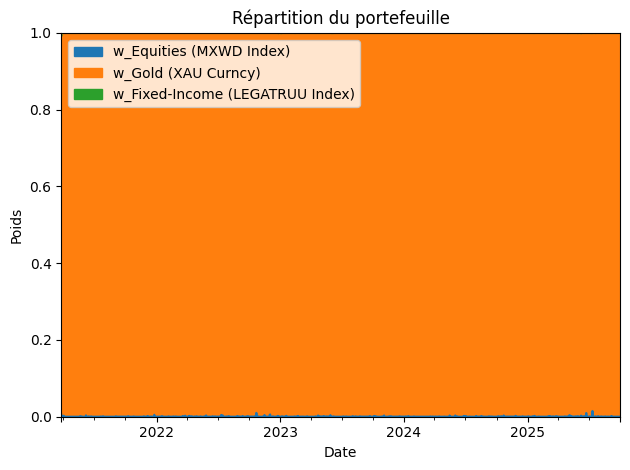

In [378]:
def get_ppo_weights(agent, env):
    """
    Exécute le PPO en mode déterministe et retourne
    uniquement les poids du portefeuille dans le temps.

    Output:
        DataFrame index=date, colonnes = w_<asset>
    """
    state = env.reset()
    done = False
    rows = []

    cols = list(env.returns_df.columns)

    while not done:
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            features = agent.feature_layer(s.unsqueeze(0))
            action_logits = agent.actor_mean(features).squeeze(0).cpu().numpy()

        next_state, _, done, info = env.step(action_logits)

        w = info["weights"]  # poids effectivement détenus (post-drift)
        rows.append({
            "date": pd.to_datetime(info["date"]),
            **{f"w_{cols[i]}": float(w[i]) for i in range(len(cols))}
        })

        state = next_state if next_state is not None else state

    weights_df = pd.DataFrame(rows).set_index("date").sort_index()
    return weights_df

weights_ppo = get_ppo_weights(trainer.agent, env_test)

plt.figure()
weights_ppo.plot.area()
plt.title("Répartition du portefeuille")
plt.ylabel("Poids")
plt.xlabel("Date")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.tight_layout()


This behavior is expected: without any diversification or risk penalty in the reward, PPO converges to a corner solution and allocates almost 100% of the portfolio to gold, which exhibits the highest cumulative return.


## Backtesting from Portfolio Weights

The PPO agent is evaluated by **decoupling learning from performance measurement**.  
The agent only provides a sequence of portfolio weights, while the backtest recomputes the true financial performance.

At each day:
- the portfolio is rebalanced according to the agent’s weights,
- transaction costs are applied based on turnover,
- daily asset returns are applied to update the portfolio value.

This ensures that performance metrics reflect **realistic trading mechanics**, independent of the reward used during training.


In [371]:
def backtest_ppo_env_timing(weights_ppo, returns_df, costs, nav0=1.0):
    """
    Backtest calé sur la temporalité de PortfolioEnv.step():

    - weights_ppo[t] est supposé être info["weights"] => poids driftés fin de journée t (EOD).
    - On reconstruit w_trade(t) (poids utilisés pendant la journée t) via "un-drift".
    - Coûts: costs · |w_trade(t) - w_eod(t-1)|
    - PnL jour t: w_trade(t) · r_t
    """

    w_cols = list(weights_ppo.columns)
    assets = [c.replace("w_", "") for c in w_cols]

    W_eod = weights_ppo[w_cols].values
    R = returns_df[assets].values
    dates = weights_ppo.index

    nav = nav0
    rows = []

    # w_prev = poids fin de journée précédente (EOD t-1)
    w_prev_eod = W_eod[0]

    # on commence à t=1 pour avoir un w_prev_eod cohérent
    for t in range(1, len(dates)):
        r_t = R[t]          # rendement du jour t (même date indexée)
        w_eod_t = W_eod[t]  # poids driftés fin de journée t (observés)

        # "un-drift": approx des poids tradés (poids tenus pendant la journée)
        w_trade = w_eod_t / (1.0 + r_t)
        w_trade = w_trade / (w_trade.sum() + 1e-12)

        trade = np.abs(w_trade - w_prev_eod)
        tc = float(np.dot(costs, trade))

        gross = float(np.dot(w_trade, r_t))
        net = gross - tc
        nav *= (1.0 + net)

        rows.append({
            "date": dates[t],
            "nav": nav,
            "gross_ret": gross,
            "tc": tc,
            "net_ret": net,
            "turnover_L1": float(trade.sum()),
            **{w_cols[i]: float(w_eod_t[i]) for i in range(len(w_cols))}
        })

        w_prev_eod = w_eod_t

    bt = pd.DataFrame(rows).set_index("date")
    bt["cum_return"] = bt["nav"] / bt["nav"].iloc[0] - 1.0
    return bt


In [372]:
def perf_stats(bt: pd.DataFrame, ann_factor: int = 252) -> dict:


    r = bt["net_ret"].dropna()
    nav = bt["nav"].dropna()

    ann_return = float(r.mean() * ann_factor)
    ann_vol = float(r.std(ddof=1) * np.sqrt(ann_factor))
    sharpe = ann_return / (ann_vol + 1e-12)
    years = len(r) / ann_factor
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    drawdown = nav / nav.cummax() - 1.0
    max_dd = float(drawdown.min())
    avg_turnover = float(bt["turnover_L1"].mean()) if "turnover_L1" in bt.columns else np.nan

    avg_annual_tc_bps = (
        float(bt["tc"].mean() * ann_factor * 1e4)
        if "tc" in bt.columns else np.nan
    )

    return {
        "CAGR": cagr,
        "AnnReturn": ann_return,
        "AnnVol": ann_vol,
        "Sharpe": sharpe,
        "MaxDrawdown": max_dd,
        "AvgDailyTurnover_L1": avg_turnover,
        "AvgAnnualTC_bps": avg_annual_tc_bps,
        "FinalNAV": float(nav.iloc[-1]),
    }


In [373]:
# Extraire uniquement les poids PPO

# Backtest réel
bt_ppo = backtest_ppo_env_timing(
    weights_ppo=weights_ppo,
    returns_df=df_test,
    costs=np.array([0.0005, 0.0010, 0.0002]),
    nav0=1.0
)

# Stats (avec ta fonction existante)
stats_ppo = perf_stats(bt_ppo)

print("=== PPO – Backtest réel (depuis les poids) ===")
for k, v in stats_ppo.items():
    print(f"{k}: {v:.4f}")


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.1189
AnnReturn: 0.1198
AnnVol: 0.1220
Sharpe: 0.9823
MaxDrawdown: -0.2466
AvgDailyTurnover_L1: 0.1679
AvgAnnualTC_bps: 213.0677
FinalNAV: 1.6603


## PPO Backtest Results Interpretation

The PPO strategy delivers a **solid long-term performance**, with a CAGR of approximately **11.9%** and a final portfolio value of **1.66**, indicating meaningful wealth accumulation over the test period.

The annualized volatility (**12.2%**) remains moderate, resulting in a **Sharpe ratio close to 1**, which reflects a reasonable risk-adjusted performance for a fully invested strategy.

However, the strategy experiences a **significant maximum drawdown of −24.7%**, highlighting its exposure to adverse market regimes and the absence of strong downside protection.

The **average daily turnover (≈17%)** is quite high that doesnt seems to suit the repartition with all on gold.

Overall, the results confirm that PPO can learn a profitable allocation policy, but also underline the importance of incorporating explicit constraints or penalties to control trading intensity and drawdowns.


In [374]:
def run_ppo_experiment(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    window_size: int,
    total_steps: int,
    lambda_var: float,
    lambda_herf: float,
):
    """
    Lance le pipeline PPO (train/test), plot les poids et affiche les stats du backtest réel.

    Prérequis déjà définis dans le notebook :
      - cost_bps
      - PortfolioEnv, PPOTrainer, set_seed
      - get_ppo_weights
      - backtest_ppo_env_timing
      - perf_stats
      - DEVICE
    """

    # --- Environnements
    env_train = PortfolioEnv(
        df_train,
        window_size=window_size,
        cost_bps=cost_bps,
        lambda_var=lambda_var,
        lambda_herf=lambda_herf,
    )

    env_test = PortfolioEnv(
        df_test,
        window_size=window_size,
        cost_bps=cost_bps,
        lambda_var=lambda_var,
        lambda_herf=lambda_herf,
    )

    # --- Entraînement
    set_seed(42)
    trainer = PPOTrainer(env_train)
    trainer.train(total_steps=total_steps)

    # --- Poids PPO
    weights_ppo = get_ppo_weights(trainer.agent, env_test)

    plt.figure(figsize=(12, 5))
    weights_ppo.plot.area(ax=plt.gca())
    plt.title(
        f"PPO – Répartition du portefeuille\n"
        f"window={window_size}, steps={total_steps}, "
        f"lambda_var={lambda_var}, lambda_herf={lambda_herf}"
    )
    plt.ylabel("Poids")
    plt.xlabel("Date")
    plt.ylim(0, 1)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # --- Backtest réel (timing cohérent avec l'env)
    bt_ppo = backtest_ppo_env_timing(
        weights_ppo=weights_ppo,
        returns_df=df_test,
        costs=cost_bps,
        nav0=1.0,
    )

    # --- Stats
    stats = perf_stats(bt_ppo)

    print("\n=== PPO – Backtest réel (depuis les poids) ===")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")

    return weights_ppo, bt_ppo, stats


Here are some example runs with different hyperparameters:


Run PPO | window=50, steps=100000, lambda_var=0.0, lambda_herf=0.0


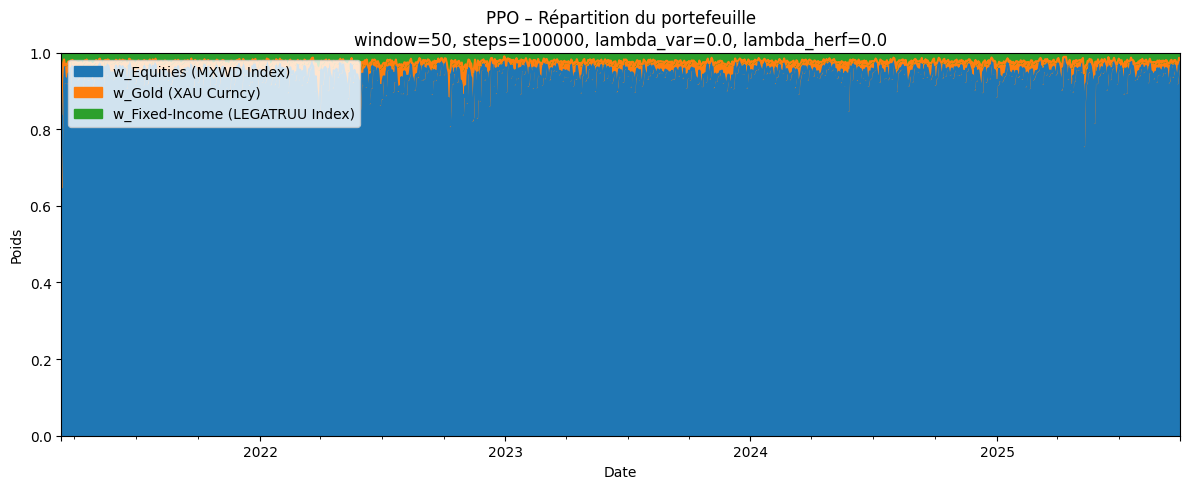


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0753
AnnReturn: 0.0813
AnnVol: 0.1314
Sharpe: 0.6186
MaxDrawdown: -0.2695
AvgDailyTurnover_L1: 0.0391
AvgAnnualTC_bps: 63.1232
FinalNAV: 1.4079

Run PPO | window=50, steps=100000, lambda_var=0.0, lambda_herf=0.05


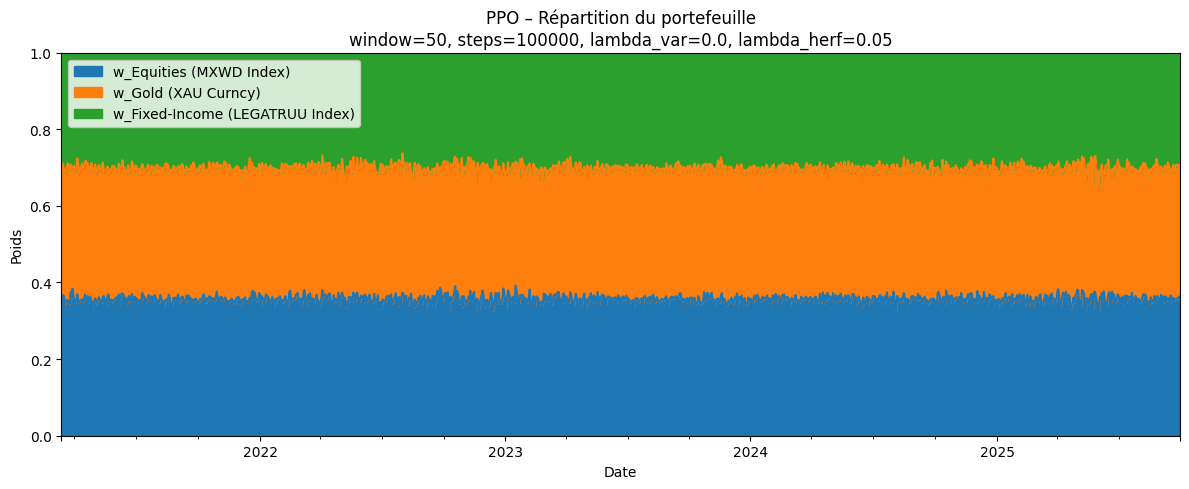


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0589
AnnReturn: 0.0609
AnnVol: 0.0861
Sharpe: 0.7076
MaxDrawdown: -0.2081
AvgDailyTurnover_L1: 0.0301
AvgAnnualTC_bps: 41.6977
FinalNAV: 1.3092

Run PPO | window=50, steps=100000, lambda_var=0.1, lambda_herf=0.0


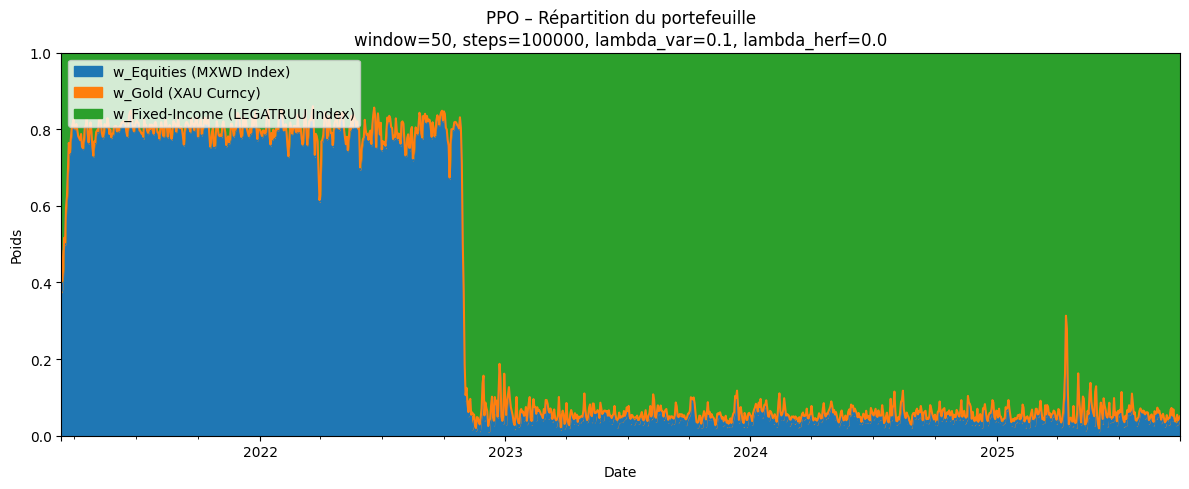


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0081
AnnReturn: 0.0119
AnnVol: 0.0871
Sharpe: 0.1361
MaxDrawdown: -0.2289
AvgDailyTurnover_L1: 0.0401
AvgAnnualTC_bps: 41.6858
FinalNAV: 1.0387

Run PPO | window=50, steps=100000, lambda_var=0.1, lambda_herf=0.05


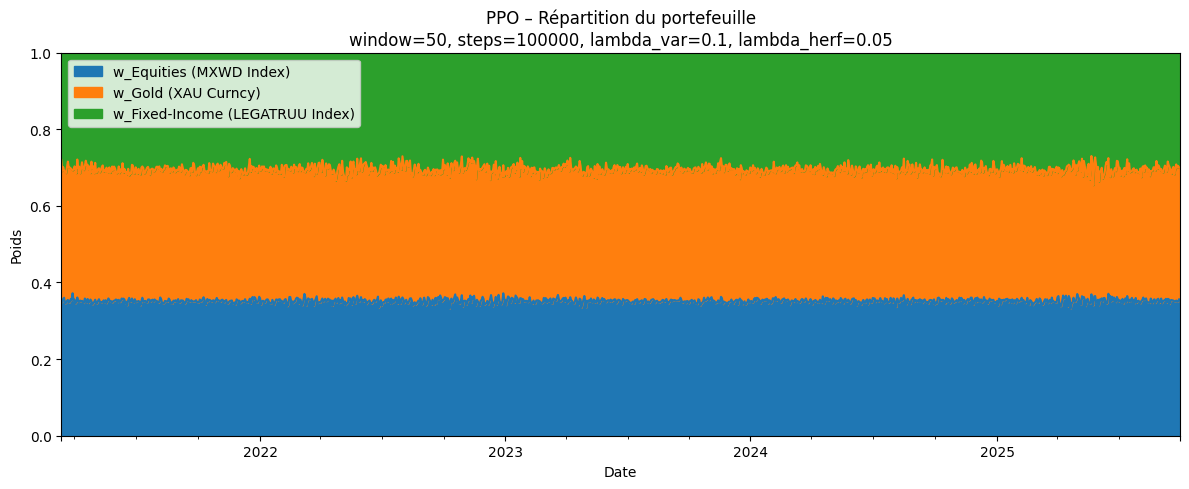


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0570
AnnReturn: 0.0592
AnnVol: 0.0859
Sharpe: 0.6889
MaxDrawdown: -0.2097
AvgDailyTurnover_L1: 0.0273
AvgAnnualTC_bps: 39.3643
FinalNAV: 1.2986

Run PPO | window=50, steps=200000, lambda_var=0.0, lambda_herf=0.0


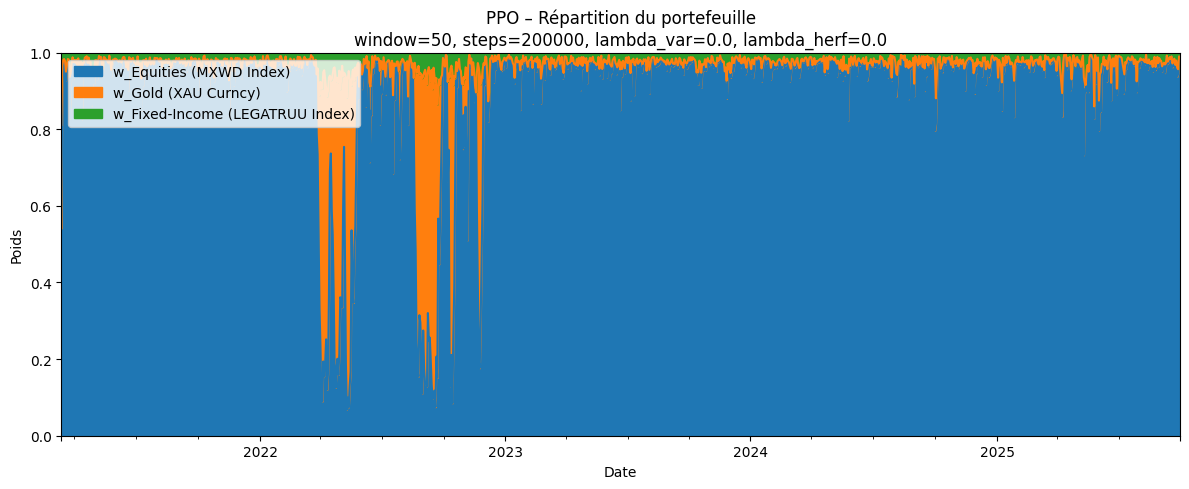


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.1042
AnnReturn: 0.1072
AnnVol: 0.1271
Sharpe: 0.8431
MaxDrawdown: -0.2450
AvgDailyTurnover_L1: 0.0726
AvgAnnualTC_bps: 110.3324
FinalNAV: 1.5947

Run PPO | window=50, steps=200000, lambda_var=0.0, lambda_herf=0.05


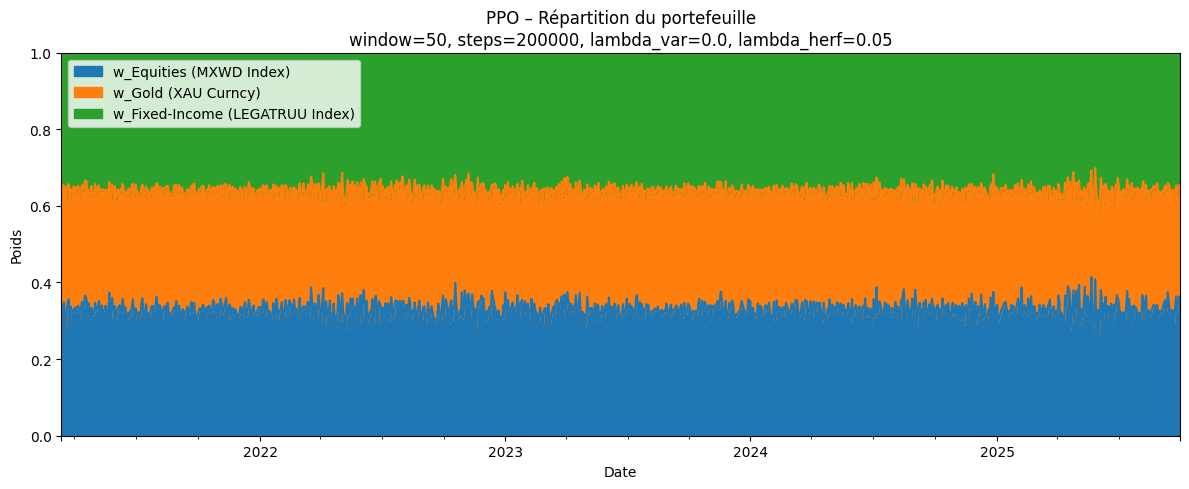


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0480
AnnReturn: 0.0502
AnnVol: 0.0820
Sharpe: 0.6124
MaxDrawdown: -0.2133
AvgDailyTurnover_L1: 0.0450
AvgAnnualTC_bps: 58.8149
FinalNAV: 1.2469

Run PPO | window=50, steps=200000, lambda_var=0.1, lambda_herf=0.0


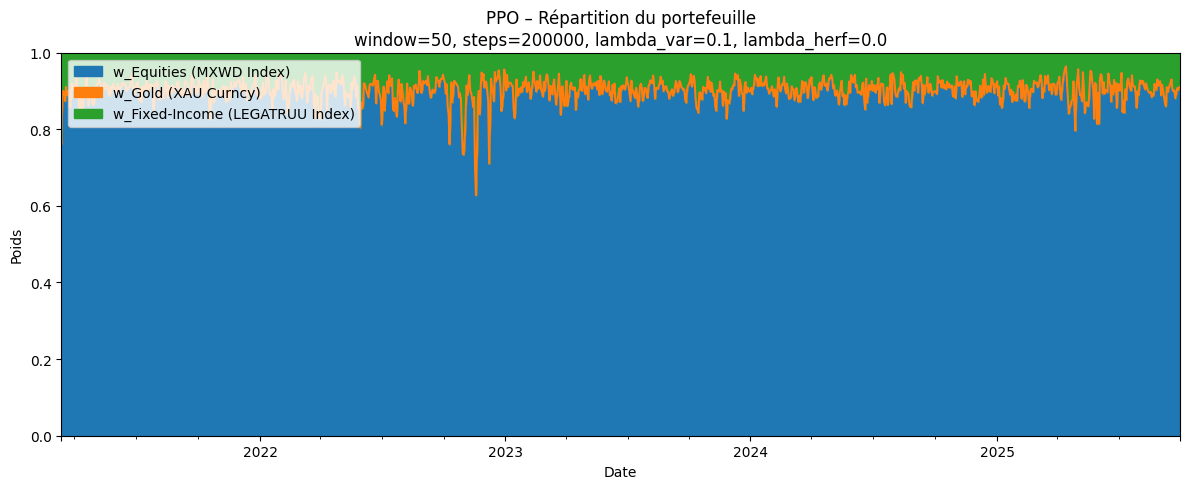


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0640
AnnReturn: 0.0700
AnnVol: 0.1262
Sharpe: 0.5546
MaxDrawdown: -0.2785
AvgDailyTurnover_L1: 0.0433
AvgAnnualTC_bps: 38.9655
FinalNAV: 1.3394

Run PPO | window=50, steps=200000, lambda_var=0.1, lambda_herf=0.05


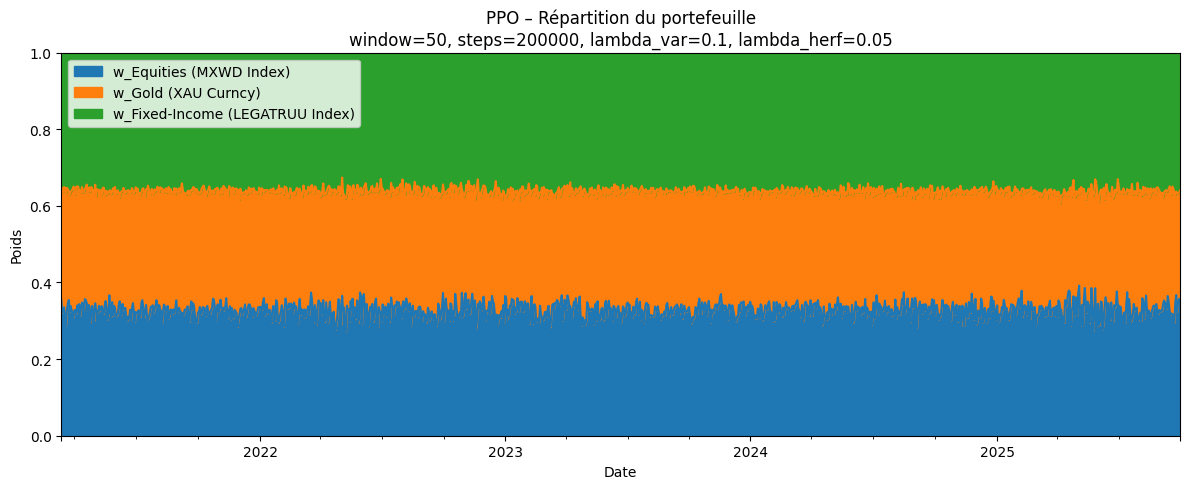


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0446
AnnReturn: 0.0469
AnnVol: 0.0820
Sharpe: 0.5728
MaxDrawdown: -0.2168
AvgDailyTurnover_L1: 0.0483
AvgAnnualTC_bps: 78.7886
FinalNAV: 1.2279

Run PPO | window=100, steps=100000, lambda_var=0.0, lambda_herf=0.0


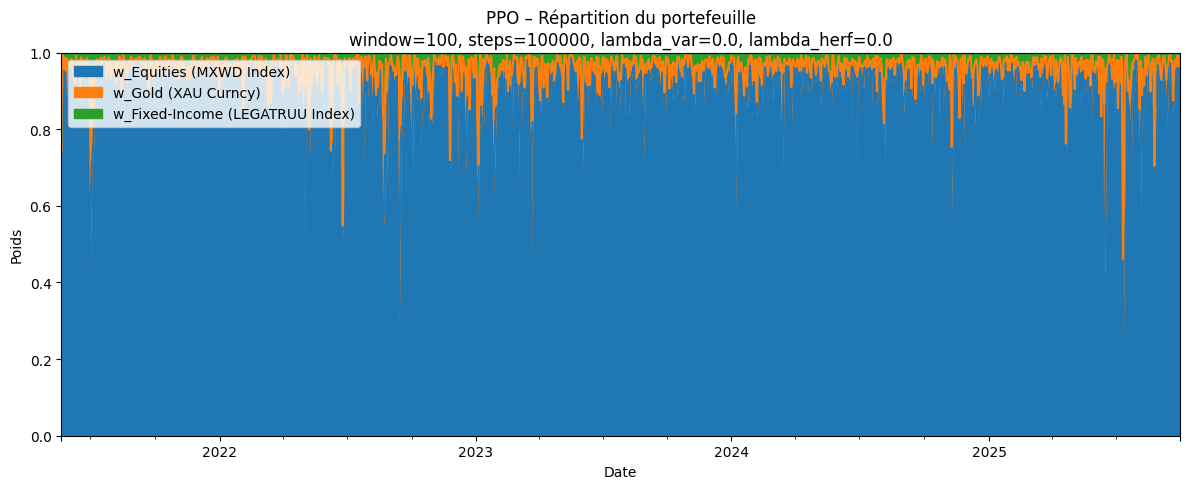


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0399
AnnReturn: 0.0475
AnnVol: 0.1295
Sharpe: 0.3665
MaxDrawdown: -0.2953
AvgDailyTurnover_L1: 0.1226
AvgAnnualTC_bps: 182.9016
FinalNAV: 1.1928

Run PPO | window=100, steps=100000, lambda_var=0.0, lambda_herf=0.05


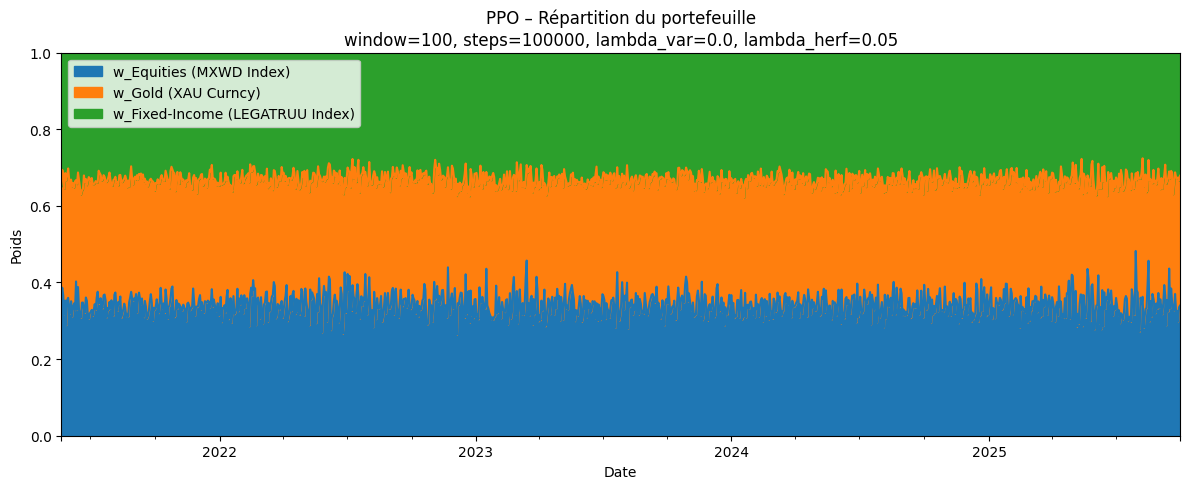


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0224
AnnReturn: 0.0258
AnnVol: 0.0853
Sharpe: 0.3021
MaxDrawdown: -0.2379
AvgDailyTurnover_L1: 0.0765
AvgAnnualTC_bps: 118.0604
FinalNAV: 1.1051

Run PPO | window=100, steps=100000, lambda_var=0.1, lambda_herf=0.0


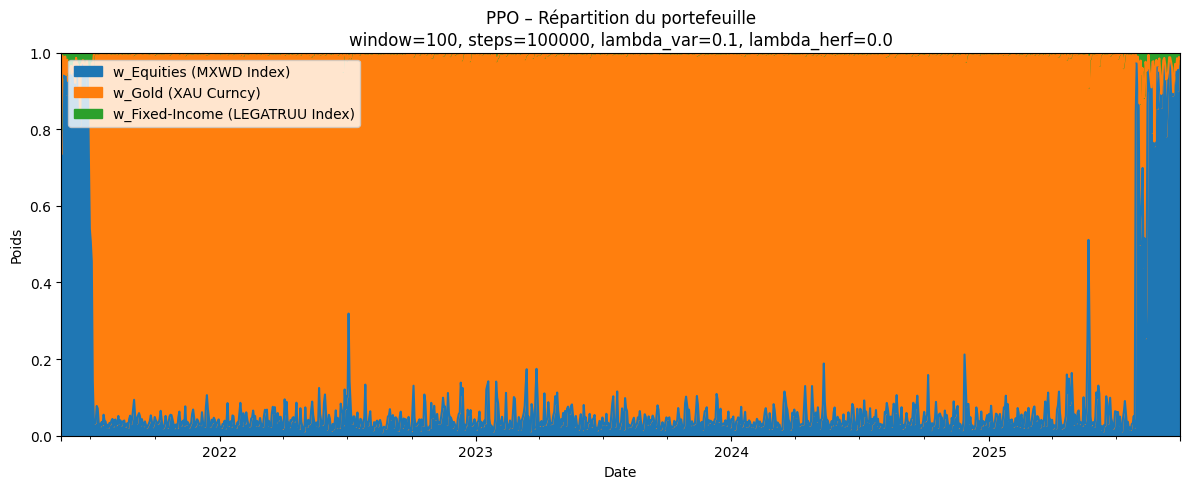


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.1092
AnnReturn: 0.1133
AnnVol: 0.1387
Sharpe: 0.8169
MaxDrawdown: -0.2146
AvgDailyTurnover_L1: 0.0571
AvgAnnualTC_bps: 101.4464
FinalNAV: 1.5965

Run PPO | window=100, steps=100000, lambda_var=0.1, lambda_herf=0.05


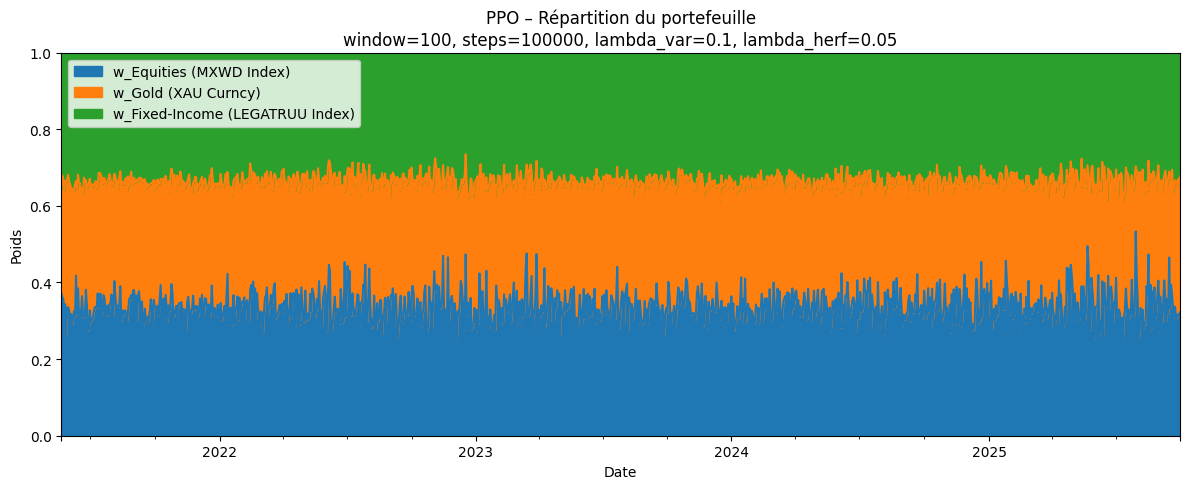


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0177
AnnReturn: 0.0212
AnnVol: 0.0853
Sharpe: 0.2484
MaxDrawdown: -0.2423
AvgDailyTurnover_L1: 0.0935
AvgAnnualTC_bps: 148.5680
FinalNAV: 1.0824

Run PPO | window=100, steps=200000, lambda_var=0.0, lambda_herf=0.0


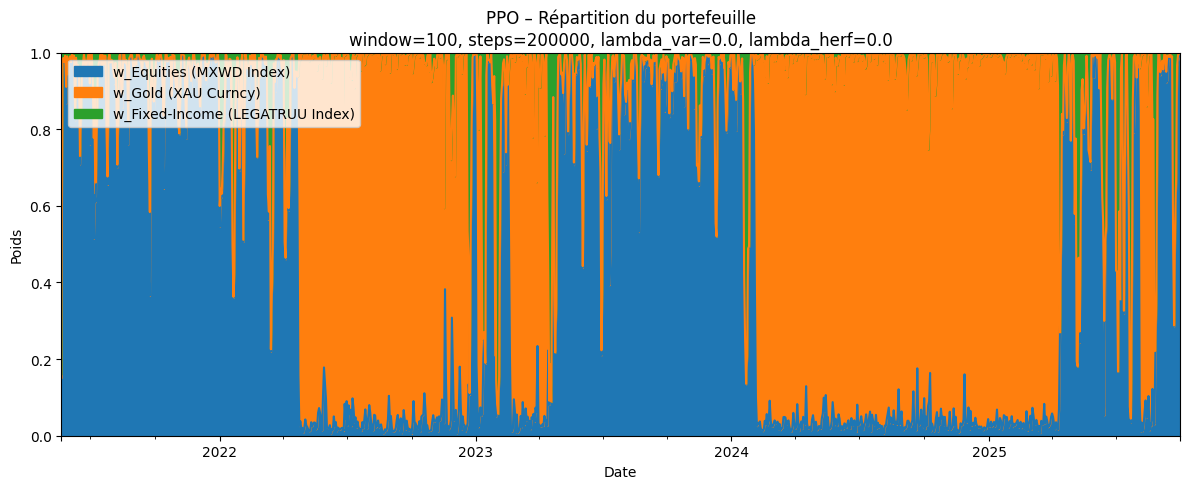


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.1189
AnnReturn: 0.1198
AnnVol: 0.1220
Sharpe: 0.9823
MaxDrawdown: -0.2466
AvgDailyTurnover_L1: 0.1679
AvgAnnualTC_bps: 213.0677
FinalNAV: 1.6603

Run PPO | window=100, steps=200000, lambda_var=0.0, lambda_herf=0.05


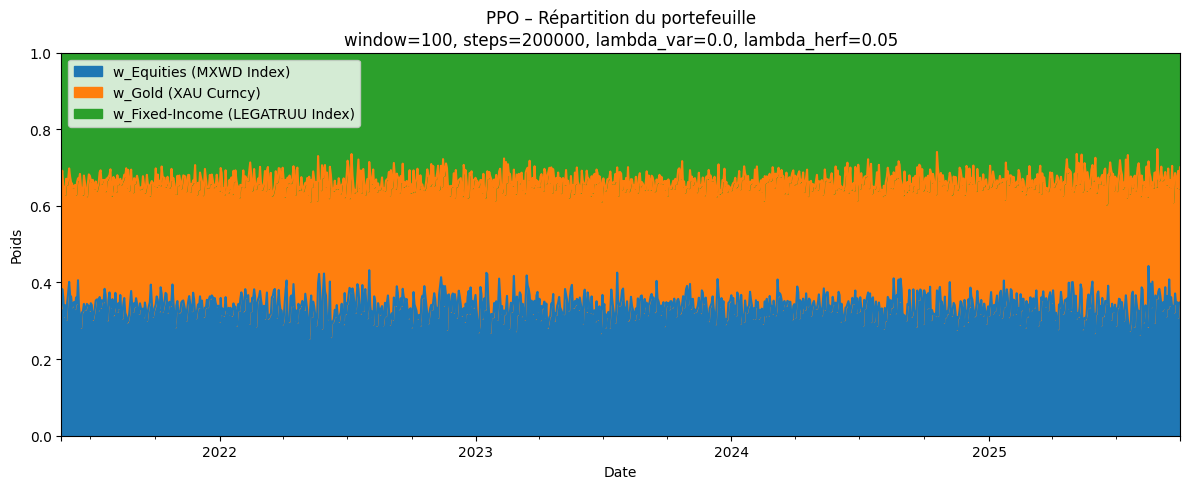


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0301
AnnReturn: 0.0333
AnnVol: 0.0851
Sharpe: 0.3913
MaxDrawdown: -0.2299
AvgDailyTurnover_L1: 0.0878
AvgAnnualTC_bps: 136.1194
FinalNAV: 1.1432

Run PPO | window=100, steps=200000, lambda_var=0.1, lambda_herf=0.0


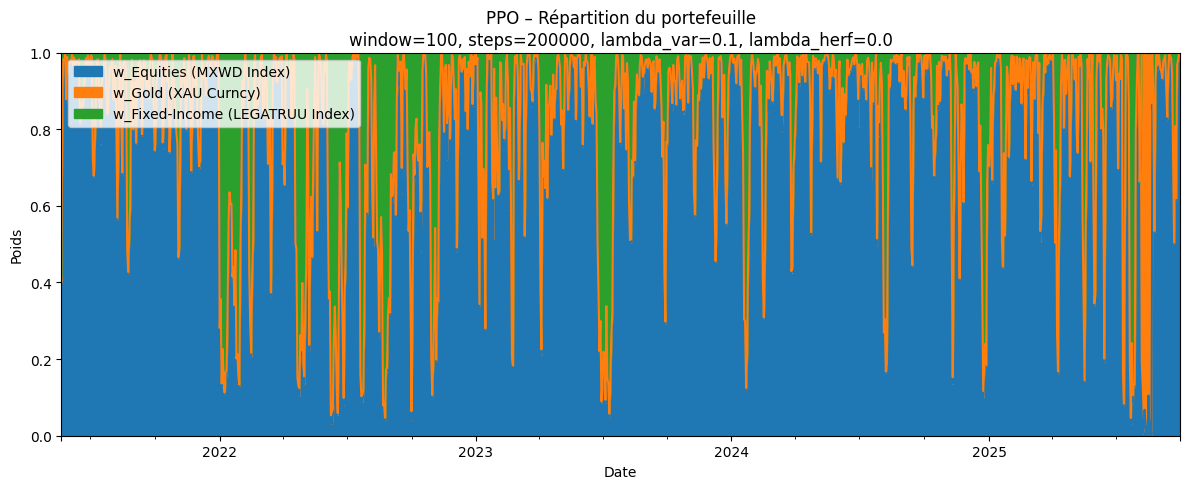


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0711
AnnReturn: 0.0757
AnnVol: 0.1179
Sharpe: 0.6416
MaxDrawdown: -0.2993
AvgDailyTurnover_L1: 0.2242
AvgAnnualTC_bps: 215.3626
FinalNAV: 1.3635

Run PPO | window=100, steps=200000, lambda_var=0.1, lambda_herf=0.05


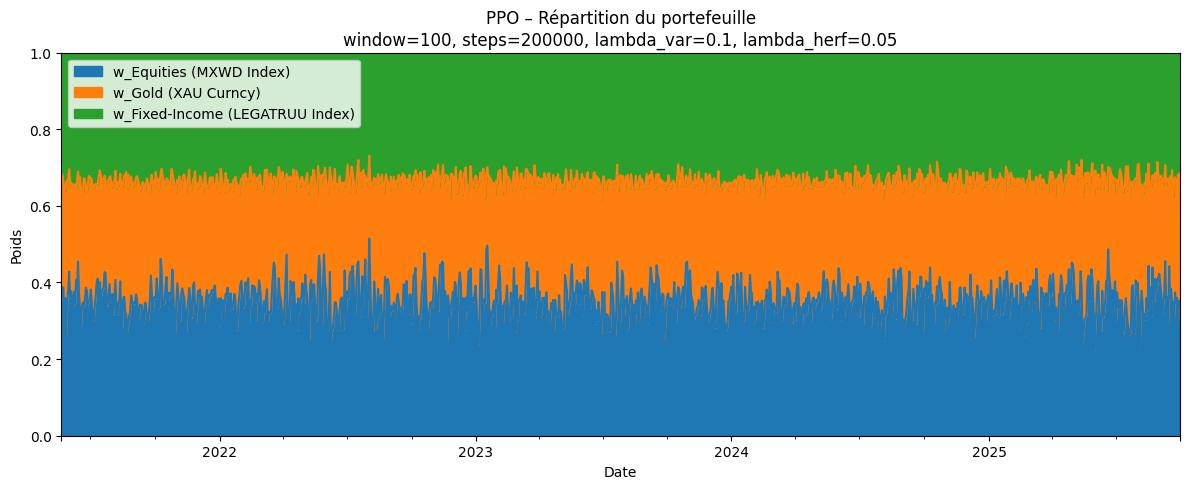


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0241
AnnReturn: 0.0275
AnnVol: 0.0853
Sharpe: 0.3223
MaxDrawdown: -0.2392
AvgDailyTurnover_L1: 0.0954
AvgAnnualTC_bps: 153.2923
FinalNAV: 1.1136


In [376]:
# Grille de paramètres
window_sizes = [50, 100]
total_steps_list = [100_000, 200_000]
lambda_vars = [0.0, 0.1]
lambda_herfs = [0.0, 0.05]

results = []

for window_size in window_sizes:
    for total_steps in total_steps_list:
        for lambda_var in lambda_vars:
            for lambda_herf in lambda_herfs:

                print("\n" + "=" * 80)
                print(
                    f"Run PPO | window={window_size}, "
                    f"steps={total_steps}, "
                    f"lambda_var={lambda_var}, "
                    f"lambda_herf={lambda_herf}"
                )

                weights_ppo, bt_ppo, stats = run_ppo_experiment(
                    df_train=df_train,
                    df_test=df_test,
                    window_size=window_size,
                    total_steps=total_steps,
                    lambda_var=lambda_var,
                    lambda_herf=lambda_herf,
                )

                # Stocker les résultats
                results.append({
                    "window_size": window_size,
                    "total_steps": total_steps,
                    "lambda_var": lambda_var,
                    "lambda_herf": lambda_herf,
                    **stats
                })


## Sensitivity Analysis and Regularization Effects

For `total_steps = 100,000`, the PPO model is **clearly undertrained**. Allocation paths are unstable and performance remains well below the best configurations observed at 200,000 steps, indicating that the policy has not converged.

Adding a **variance penalty (`lambda_var = 0.1`)** slightly reduces volatility but significantly hurts performance.  
For `window=100`, `steps=200,000`:
- Annualized volatility decreases marginally from **12.2%** to **11.8%**,
- Annualized return drops from **12.0%** to **7.6%**,
- Sharpe ratio falls from **0.98** to **0.64**.

The **Herfindahl penalty (`lambda_herf = 0.05`)** has a much stronger impact.  
In the same configuration:
- Annualized return collapses to **3.3%**,
- Volatility decreases to **8.5%**,
- Sharpe ratio drops to **0.39**,
- Final NAV falls from **1.66** to **1.14**.

Allocation plots confirm that this penalty drives the portfolio toward a near **equal-weight (1/3–1/3–1/3) solution**, effectively neutralizing the agent’s ability to exploit asset-specific returns.

Overall, PPO performance is **highly sensitive to both the observation window size and the number of training steps**. Sufficient training is essential, and overly strong regularization can dominate the learning signal and degrade performance.



Run PPO | window=50, steps=600000, lambda_var=0.0, lambda_herf=0.0


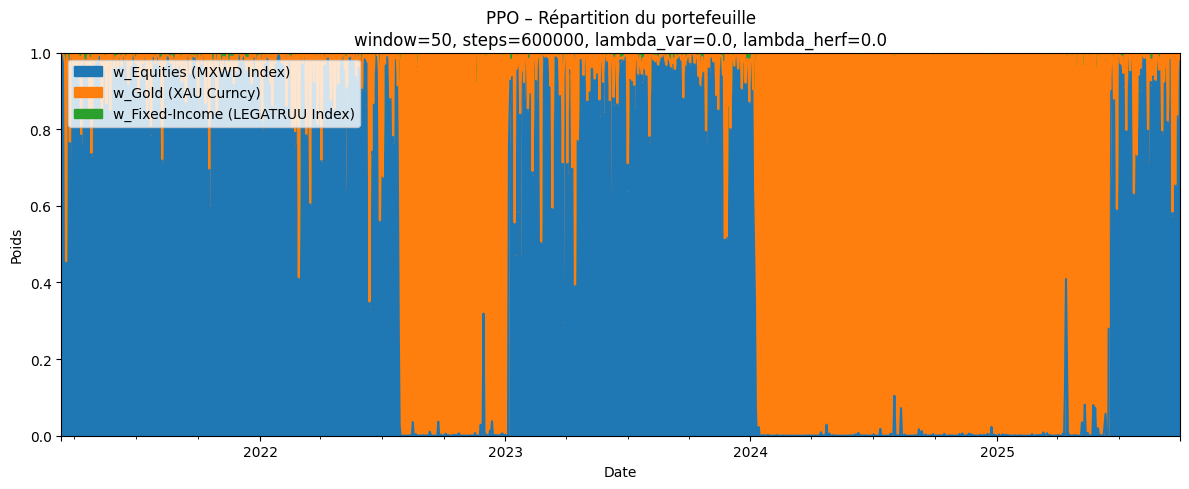


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.1119
AnnReturn: 0.1151
AnnVol: 0.1339
Sharpe: 0.8597
MaxDrawdown: -0.2681
AvgDailyTurnover_L1: 0.1087
AvgAnnualTC_bps: 123.3820
FinalNAV: 1.6484

Run PPO | window=50, steps=600000, lambda_var=0.0, lambda_herf=0.05


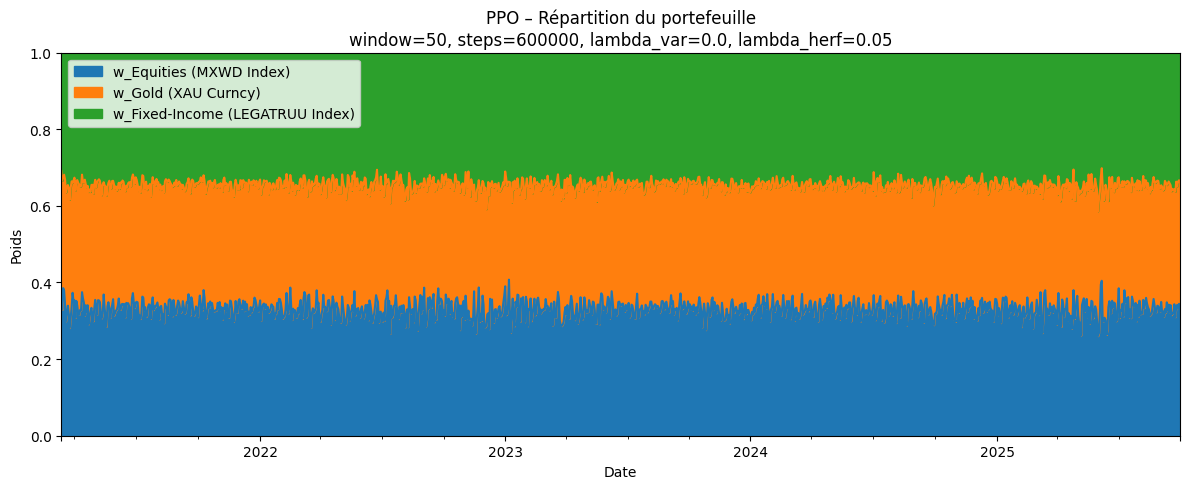


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0575
AnnReturn: 0.0593
AnnVol: 0.0829
Sharpe: 0.7152
MaxDrawdown: -0.2049
AvgDailyTurnover_L1: 0.0516
AvgAnnualTC_bps: 76.5648
FinalNAV: 1.3011

Run PPO | window=50, steps=600000, lambda_var=0.1, lambda_herf=0.0


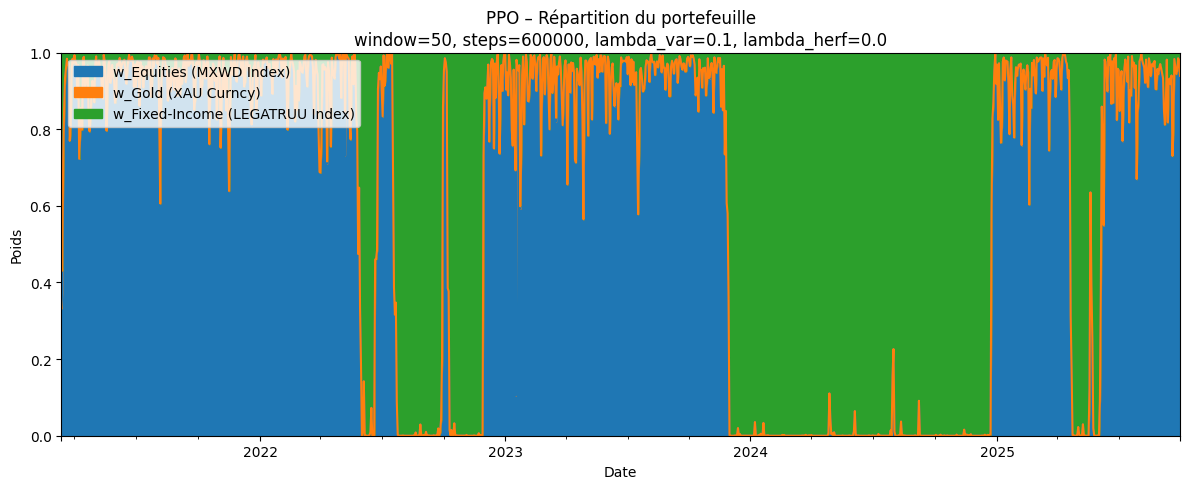


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0430
AnnReturn: 0.0485
AnnVol: 0.1129
Sharpe: 0.4294
MaxDrawdown: -0.2930
AvgDailyTurnover_L1: 0.0970
AvgAnnualTC_bps: 88.7535
FinalNAV: 1.2194

Run PPO | window=50, steps=600000, lambda_var=0.1, lambda_herf=0.05


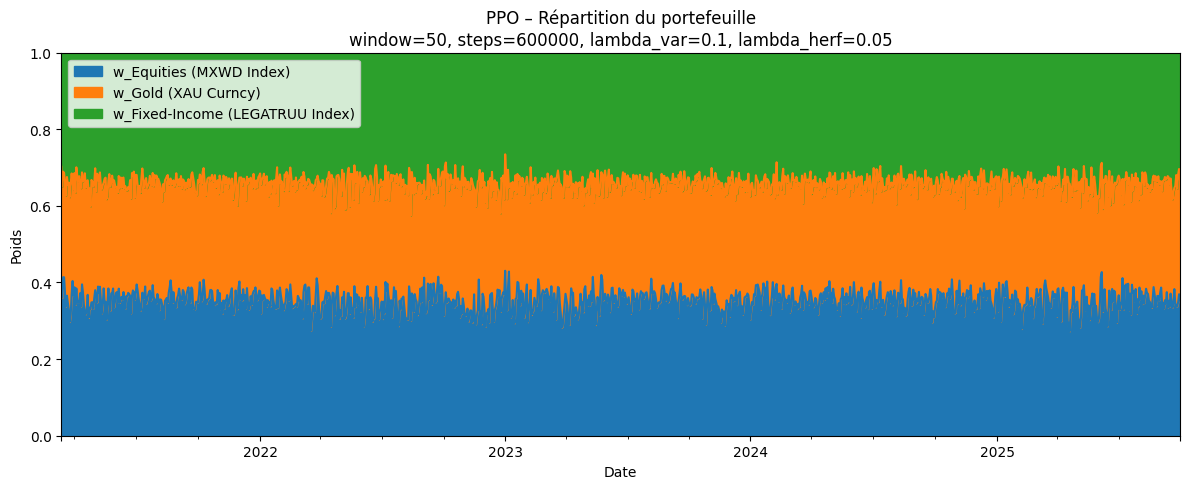


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0499
AnnReturn: 0.0522
AnnVol: 0.0828
Sharpe: 0.6299
MaxDrawdown: -0.2129
AvgDailyTurnover_L1: 0.0712
AvgAnnualTC_bps: 101.6336
FinalNAV: 1.2581

Run PPO | window=100, steps=600000, lambda_var=0.0, lambda_herf=0.0


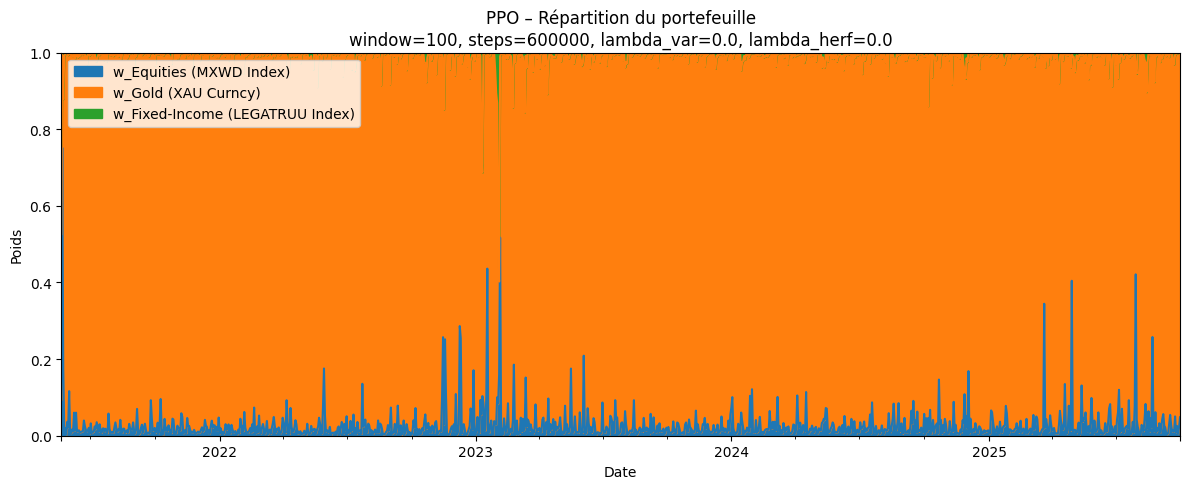


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0921
AnnReturn: 0.0982
AnnVol: 0.1419
Sharpe: 0.6919
MaxDrawdown: -0.2189
AvgDailyTurnover_L1: 0.0704
AvgAnnualTC_bps: 116.7877
FinalNAV: 1.4881

Run PPO | window=100, steps=600000, lambda_var=0.0, lambda_herf=0.05


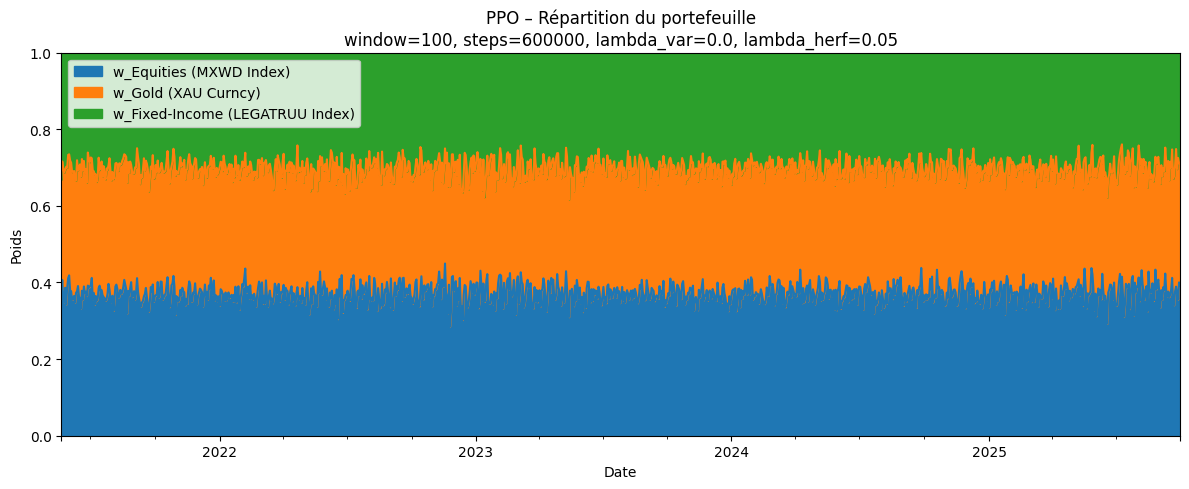


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0395
AnnReturn: 0.0425
AnnVol: 0.0870
Sharpe: 0.4886
MaxDrawdown: -0.2255
AvgDailyTurnover_L1: 0.0666
AvgAnnualTC_bps: 89.6425
FinalNAV: 1.1910

Run PPO | window=100, steps=600000, lambda_var=0.1, lambda_herf=0.0


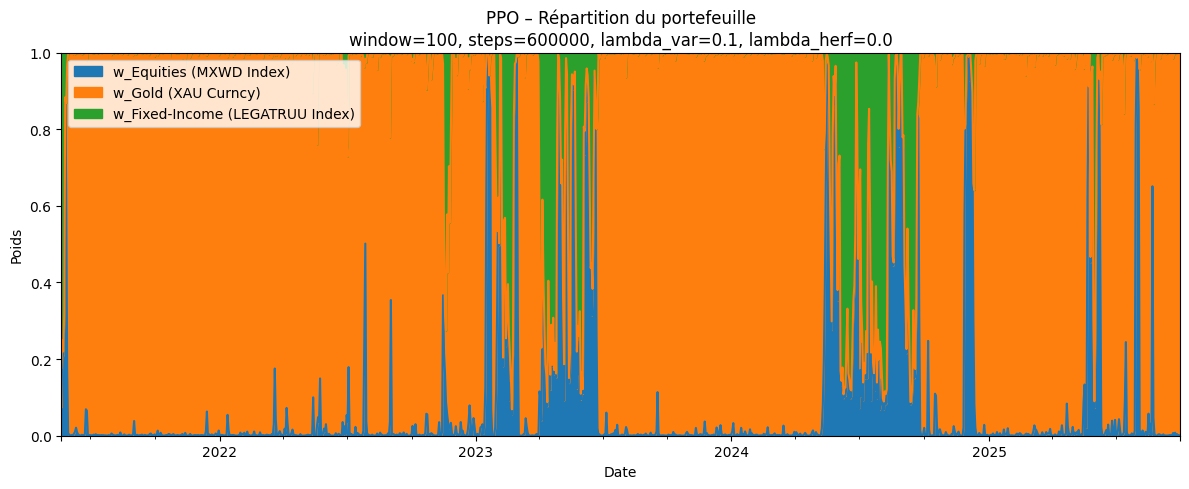


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0520
AnnReturn: 0.0600
AnnVol: 0.1366
Sharpe: 0.4391
MaxDrawdown: -0.2609
AvgDailyTurnover_L1: 0.1226
AvgAnnualTC_bps: 168.0751
FinalNAV: 1.2568

Run PPO | window=100, steps=600000, lambda_var=0.1, lambda_herf=0.05


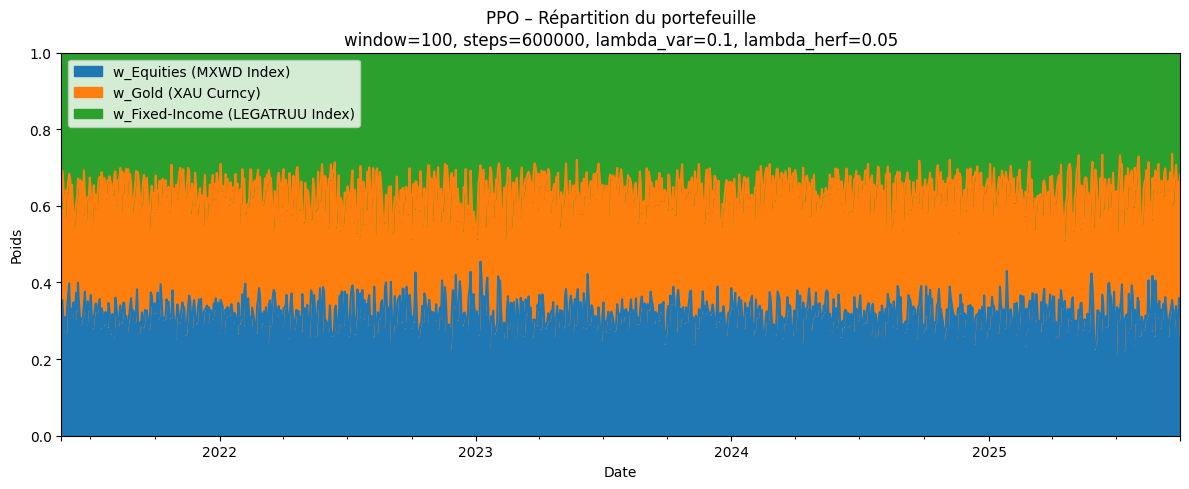


=== PPO – Backtest réel (depuis les poids) ===
CAGR: 0.0157
AnnReturn: 0.0191
AnnVol: 0.0838
Sharpe: 0.2279
MaxDrawdown: -0.2507
AvgDailyTurnover_L1: 0.1307
AvgAnnualTC_bps: 200.4249
FinalNAV: 1.0729


In [381]:
# Grille de paramètres
window_sizes = [50, 100]
total_steps_list = [600_000]
lambda_vars = [0.0, 0.1]
lambda_herfs = [0.0, 0.05]

results = []

for window_size in window_sizes:
    for total_steps in total_steps_list:
        for lambda_var in lambda_vars:
            for lambda_herf in lambda_herfs:

                print("\n" + "=" * 80)
                print(
                    f"Run PPO | window={window_size}, "
                    f"steps={total_steps}, "
                    f"lambda_var={lambda_var}, "
                    f"lambda_herf={lambda_herf}"
                )

                weights_ppo, bt_ppo, stats = run_ppo_experiment(
                    df_train=df_train,
                    df_test=df_test,
                    window_size=window_size,
                    total_steps=total_steps,
                    lambda_var=lambda_var,
                    lambda_herf=lambda_herf,
                )

                # Stocker les résultats
                results.append({
                    "window_size": window_size,
                    "total_steps": total_steps,
                    "lambda_var": lambda_var,
                    "lambda_herf": lambda_herf,
                    **stats
                })


## Effect of Longer Training (600,000 Steps)

When increasing the training horizon to **600,000 steps**, the PPO policy **fully converges to corner solutions**, confirming earlier observations.

For `window=100`, `lambda_var=0`, `lambda_herf=0`, the agent allocates **almost entirely to gold**.  
This results in:
- CAGR ≈ **9.2%**,
- Volatility ≈ **14.2%**,
- Sharpe ≈ **0.69**,
- Final NAV ≈ **1.49**.

Compared to the 200,000-step case, returns and Sharpe **decline**, indicating that longer training reinforces over-specialization rather than improving risk-adjusted performance.

Introducing **both variance and Herfindahl penalties** (`lambda_var=0.1`, `lambda_herf=0.05`) does not improve results:
- CAGR drops to **~5%**,
- Sharpe remains low (**~0.63**),
- Final NAV stays close to **1.26**.

Finally, even without regularization, some configurations at 600,000 steps exhibit **worse performance than at 200,000 steps** (e.g. Sharpe ≈ **0.44** for `window=100`), highlighting that **more training does not necessarily lead to better policies**.

Overall, extended training amplifies the tendency of PPO to converge to dominant assets (gold), while combined regularization remains ineffective. This confirms that PPO performance is driven more by reward structure and inductive bias than by sheer training time.


In [379]:


def solve_mkv_tc(mu, Sigma, w_prev, costs, lam):
    """
    Max: mu'w - 0.5*lam*w'Sigma*w - costs'|w - w_prev|
    s.c. sum(w)=1, w>=0
    """
    n = len(mu)
    w = cp.Variable(n)
    u = cp.Variable(n)  # u >= |w - w_prev|

    obj = cp.Maximize(mu @ w - 0.5 * lam * cp.quad_form(w, Sigma) - costs @ u)
    cons = [
        cp.sum(w) == 1,
        w >= 0,  # long-only
        u >=  w - w_prev,
        u >= -(w - w_prev),
        u >= 0
    ]

    cp.Problem(obj, cons).solve(solver="OSQP", warm_start=True, verbose=False)

    if w.value is None:
        return np.asarray(w_prev).ravel()

    w_sol = np.asarray(w.value).ravel()
    w_sol = np.clip(w_sol, 0.0, None)
    s = w_sol.sum()
    if s <= 1e-12:
        return np.asarray(w_prev).ravel()
    return w_sol / s


def backtest_mkv_tc(df_returns, window=252, lam=10.0, costs=None, w0=None):
    """
    Backtest Markowitz 
    """
    X = df_returns.dropna()
    R = X.values
    dates = X.index
    n = R.shape[1]

    costs = np.zeros(n) if costs is None else np.asarray(costs).ravel()
    w_prev = np.ones(n) / n if w0 is None else np.asarray(w0).ravel()
    w_prev = np.clip(w_prev, 0.0, None)
    w_prev = w_prev / (w_prev.sum() + 1e-12)

    nav = 1.0
    rows = []

    for t in range(window, len(R) - 1):
        # estimation sans lookahead (jusqu'à t-1)
        hist = R[t - window:t]
        mu = hist.mean(axis=0)

        Sigma = np.cov(hist, rowvar=False)
        Sigma = 0.5 * (Sigma + Sigma.T) + 1e-8 * np.eye(n)  # stabilisation

        # poids cibles (pré-rendement)
        w = solve_mkv_tc(mu, Sigma, w_prev, costs, lam)

        # rendement du jour suivant
        r_next = R[t + 1]

        # coûts de transaction (one-way, en return)
        trade = np.abs(w - w_prev)
        tc = float(costs @ trade)

        gross = float(w @ r_next)
        net = gross - tc
        nav *= (1.0 + net)

        rows.append({
            "date": dates[t + 1],
            "nav": nav,
            "gross_ret": gross,
            "tc": tc,
            "net_ret": net,
            "turnover_L1": float(trade.sum()),
            **{f"w_{X.columns[i]}": float(w[i]) for i in range(n)}
        })

        # drift: poids réellement détenus après le move de marché
        w_post = w * (1.0 + r_next)
        w_prev = w_post / (w_post.sum() + 1e-12)

    return pd.DataFrame(rows).set_index("date")


def perf_stats(bt: pd.DataFrame) -> dict:
    r = bt["net_ret"].dropna()
    ann = 252.0
    if len(r) < 5:
        return {}

    mu_a = float(r.mean() * ann)
    vol_a = float(r.std(ddof=1) * np.sqrt(ann))
    sharpe = mu_a / (vol_a + 1e-12)

    years = len(r) / ann
    nav = bt["nav"].dropna()
    cagr = float(nav.iloc[-1] ** (1 / years) - 1.0)

    dd = nav / nav.cummax() - 1.0
    max_dd = float(dd.min())

    return {
        "CAGR": cagr,
        "AnnReturn": mu_a,
        "AnnVol": vol_a,
        "Sharpe": float(sharpe),
        "MaxDrawdown": max_dd,
        "AvgDailyTurnover_L1": float(bt["turnover_L1"].mean()),
        "AvgAnnualTC_bps": float(bt["tc"].mean() * ann * 1e4),
        "FinalNAV": float(nav.iloc[-1]),
    }


In [380]:
costs = np.array([0.0005, 0.0010, 0.0002])

# Backtest Markowitz avec coûts
bt_markowitz = backtest_mkv_tc(
    df_returns=df_test,
    window=252,                 # fenêtre rolling (1 an)
    lam=10.0,                   # aversion au risque (à risk-match vs PPO)
    costs=costs,
    w0=np.array([1/3, 1/3, 1/3])
)

# Statistiques de performance
stats_markowitz = perf_stats(bt_markowitz)

print("=== Markowitz + Transaction Costs ===")
for k, v in stats_markowitz.items():
    print(f"{k}: {v:.4f}")


=== Markowitz + Transaction Costs ===
CAGR: 0.1161
AnnReturn: 0.1148
AnnVol: 0.0989
Sharpe: 1.1604
MaxDrawdown: -0.1943
AvgDailyTurnover_L1: 0.0006
AvgAnnualTC_bps: 0.5114
FinalNAV: 1.5365


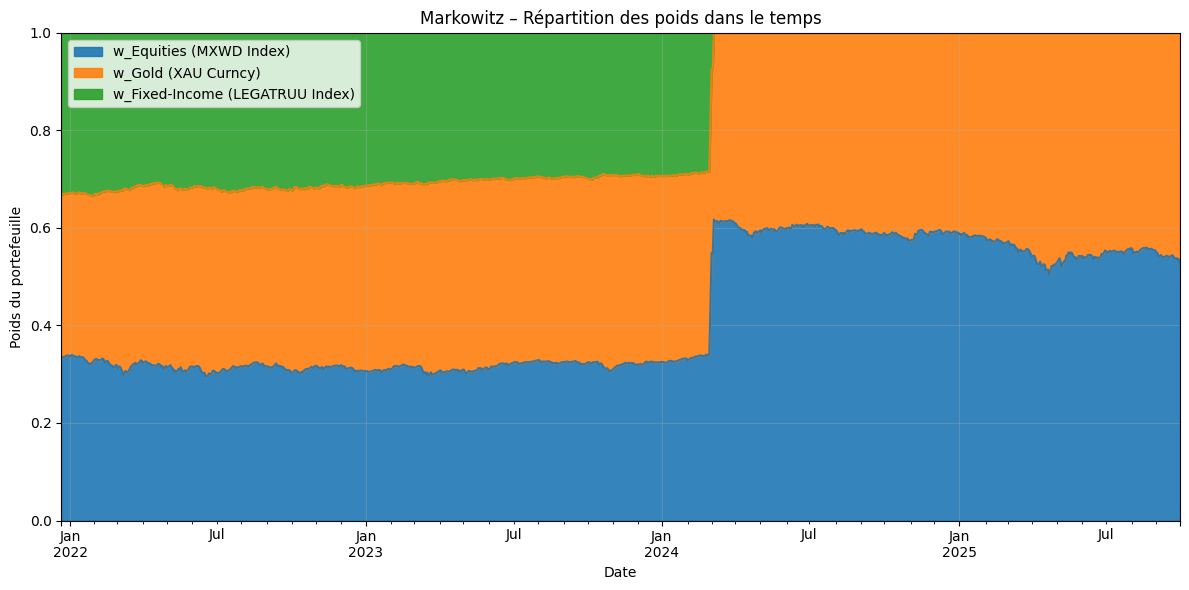

In [358]:
weight_cols = [c for c in bt_markowitz.columns if c.startswith("w_")]
weights = bt_markowitz[weight_cols]
import matplotlib.pyplot as plt

weights.plot(
    kind="area",
    stacked=True,
    figsize=(12, 6),
    alpha=0.9
)

plt.title("Markowitz – Répartition des poids dans le temps")
plt.ylabel("Poids du portefeuille")
plt.xlabel("Date")
plt.ylim(0, 1)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Comparison with Markowitz Benchmark

We compare the PPO results to a Markowitz mean–variance benchmark with transaction costs, using the same assets and backtesting conventions.

### Markowitz (with Transaction Costs)

- CAGR: **11.6%**
- Volatility: **9.9%**
- Sharpe ratio: **1.16**
- Max drawdown: **−19.4%**
- Avg annual transaction costs: **~0.5 bps**
- Final NAV: **1.54**

The Markowitz strategy delivers **excellent risk-adjusted performance**, with very low turnover and minimal transaction costs. Its allocations are stable, resulting in lower volatility and drawdowns.

---

### PPO Results (Selected Configurations)

**PPO – window=100, steps=200,000**
- CAGR: **11.9%**
- Volatility: **12.2%**
- Sharpe ratio: **0.98**
- Max drawdown: **−24.7%**
- Avg annual transaction costs: **~213 bps**
- Final NAV: **1.66**

**PPO – window=50, steps=600,000**
- CAGR: **11.2%**
- Volatility: **13.4%**
- Sharpe ratio: **0.86**
- Max drawdown: **−26.8%**
- Avg annual transaction costs: **~123 bps**
- Final NAV: **1.65**

PPO achieves **comparable or slightly higher cumulative performance (Final NAV)** than Markowitz in its best configurations, but at the cost of:
- significantly higher volatility,
- larger drawdowns,
- much higher turnover and transaction costs.

---

### Interpretation

- **Markowitz dominates in risk-adjusted terms**, with a higher Sharpe ratio, lower drawdowns, and negligible transaction costs.
- **PPO can match or exceed Markowitz in cumulative returns**, but does so by taking more risk and trading much more aggressively.
- The PPO policy tends to concentrate on the best-performing asset (gold), which boosts returns but deteriorates stability and costs.

Overall, Markowitz remains a **very strong baseline** in this low-dimensional setting, while PPO demonstrates flexibility and adaptability but requires careful reward design and regularization to compete on a risk-adjusted basis.


## Conclusion

This notebook explored dynamic portfolio allocation using **Reinforcement Learning (PPO)** and compared it to a **Markowitz mean–variance benchmark with transaction costs**, using the same assets and data.

The results show that PPO is able to learn profitable allocation policies and can **match or exceed Markowitz in cumulative performance** in its best configurations. However, this comes at the cost of **higher volatility, larger drawdowns, and significantly higher turnover and transaction costs**. In contrast, Markowitz delivers **superior risk-adjusted performance**, with lower volatility, smaller drawdowns, and very stable allocations.

An important takeaway is that PPO’s behavior is highly sensitive to the reward specification and training setup. Without sufficient regularization, the agent tends to converge to **corner solutions** (e.g. full allocation to gold), which inflate returns but deteriorate stability.

Finally, the comparison is not perfectly symmetric. A more realistic benchmark would require **aligning the optimization criteria more closely**, for example by penalizing PPO’s reward with a **rolling volatility term** or other downside-risk measures, making its objective closer to that of mean–variance optimization. Such adjustments would likely reduce turnover and improve risk-adjusted performance, leading to a fairer and more informative comparison.

Overall, this study highlights both the **potential and the limitations of RL-based portfolio construction**, and emphasizes the importance of careful reward design and benchmarking when applying reinforcement learning to real-world investment problems.
